# Searching for the Right Prompt

### A research diary on building a semantic prompt search engine for **LEAF × PromptKaban**

| Student | Matricola |
|---|---:|
| Alisa Lamina | 321961 |
| Maiia Kopalina | 321891 |
| Alice Rossi | 305091 |
| Andrea Cipolla | 319211 |

---

## Prologue — the brief that landed on our desk

A few weeks ago, LEAF showed us their upcoming product, **PromptKaban**: a "GitHub for prompt engineering" with versioning, evals, deployment, voting, forking — the whole prompt-ops stack. The platform is going to host *tens of thousands* of prompts, and keyword search just collapses at that scale. People do not type `category:marketing AND tags:cold-email`. They type *"a prompt to write a B2B cold email that doesn't sound like a robot"* and expect the right thing to show up.

The problem:

> Users need to describe what they want in natural language and find the most relevant prompts.

We treated this notebook as a small research project: each chapter is a step we actually took, including the dead ends and the moments where something surprised us.

## How this notebook reads

We wrote this notebook as a diary.

| Chapter | What we did | Why it matters |
|---|---|---|
| 1. The dataset arrives | Load PromptKaban's JSON, sanity-check the fields | If a column is missing the whole pipeline breaks silently |
| 2. Looking before leaping | Visual EDA with Plotly | Distributions tell us how to score things later |
| 3. Teaching the machine to read | Build one rich semantic text per prompt | Title + tags + content gives context the model would otherwise miss |
| 4. Building the library | Generate embeddings, store them in FAISS | This is our "vector database" — the heart of the system |
| 5. The first search | Dense + BM25 + hybrid retrieval | Two retrieval styles, one fused result |
| 6. A second opinion, then a popularity check | Cross-encoder rerank + metadata fusion (the **bonus**) | Reading query and candidate *together* beats cosine alone; popularity & freshness add the human signal |
| 7. A first end-to-end run | One natural query, end-to-end, scores exposed | Demonstrates the system works *and* is interpretable |
| 8. Honest measurement | Build a Precision@10 / MRR / latency harness | Replaces "feels better" with numbers |
| 9. Auditioning the brains | Compare three pretrained embedding models | Pick the best by quality and latency, not by intuition |
| 10. Tuning the dials | Random search over fusion weights | A small, honest hyperparameter study |
| 11. **Going agentic** | LLM-driven query rewriting + RRF + MMR | Our innovation chapter |
| 12. Closing the loop | What we built, what we'd ship next | The honest retrospective |
| 13. **Try it yourself** | `demo_search()` + an inline `ipywidgets` UI + a Streamlit `app.py` | Lets a reviewer actually type queries and see results |



In [7]:
# If needed, uncomment and run:
# !pip install -U pandas numpy scikit-learn plotly kaleido sentence-transformers rank-bm25 tqdm faiss-cpu

import os
os.environ["HF_HUB_DISABLE_PROGRESS_BARS"] = "1"
os.environ["TOKENIZERS_PARALLELISM"] = "false"

import json
import re
import time
from pathlib import Path

import numpy as np
import pandas as pd
from tqdm import tqdm

import plotly.express as px
import plotly.graph_objects as go
import plotly.io as pio
from plotly.subplots import make_subplots

# Prefer static PNG outputs so charts remain visible on GitHub.
try:
    import plotly.express as _px_test
    _fig_test = _px_test.bar(x=["test"], y=[1])
    _fig_test.to_image(format="png")
    pio.renderers.default = "png"
    print("Plotly renderer: png")
except Exception as exc:
    pio.renderers.default = "notebook_connected"
    print("Plotly renderer: notebook_connected (PNG export unavailable)")
    print("PNG export issue:", type(exc).__name__)

from sklearn.preprocessing import MinMaxScaler
from sklearn.neighbors import NearestNeighbors
from sklearn.decomposition import PCA

from rank_bm25 import BM25Okapi


# Shared Plotly layout presets (EDA + evaluation)
FIG = dict(
    paper_bgcolor="rgba(0,0,0,0)",
    plot_bgcolor="rgba(0,0,0,0)",
    margin=dict(l=50, r=30, t=60, b=50),
)
FIG_EVAL = {**FIG, "height": 480}
FIG_EVAL_WIDE = {**FIG, "height": 520, "width": 1000}
FIG_DELTA = {**FIG, "height": 580, "margin": dict(l=50, r=30, t=70, b=120)}



ASSETS_DIR = None  # set in Chapter 1 after PROJECT_ROOT
SAVE_FIGURES = True


def save_show(fig, filename: str, width=None, height=None, scale=2):
    """Display in-notebook and export PNG to assets/."""
    fig.show()
    if not SAVE_FIGURES:
        return fig
    out_dir = ASSETS_DIR
    if out_dir is None:
        return fig
    path_out = Path(out_dir) / filename
    path_out.parent.mkdir(parents=True, exist_ok=True)
    kwargs = {"scale": scale}
    if width:
        kwargs["width"] = width
    if height:
        kwargs["height"] = height
    try:
        fig.write_image(str(path_out), **kwargs)
        try:
            rel = path_out.relative_to(PROJECT_ROOT)
        except Exception:
            rel = path_out.name
        print(f"Saved figure → {rel}")
    except Exception as exc:
        print(f"Figure not exported ({type(exc).__name__}): {filename}")
    return fig

def apply_fig_layout(fig, preset=None, **overrides):
    layout = dict(preset or FIG)
    layout.update(overrides)
    fig.update_layout(**layout)
    return fig

from sentence_transformers import SentenceTransformer, CrossEncoder

Plotly renderer: png


## Chapter 1 — The dataset arrives

Before any clever retrieval, we needed to actually meet the data. LEAF shipped us a single `dataset.json` with the prompts and a `FIELDS.md` describing twenty fields per record: the obvious ones (`title`, `content`, `category`, `tags`) and the platform telemetry that makes this challenge interesting (`likes`, `upvotes`, `downvotes`, `views`, `uses`, `author_reputation`, `fork_count`, `version`, `created_at`, `difficulty`, `language`, `target_model`).

Our first instinct was to dive in, but we quickly added sanity checks at the top: homogeneous schema, unique ids, and explicit dtypes — if a column we rely on later is missing or mistyped, we want to fail *here*, not inside FAISS.

In [8]:
PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "LEAF-promptkaban-dataset").exists():
    for parent in Path.cwd().resolve().parents:
        if (parent / "LEAF-promptkaban-dataset").exists():
            PROJECT_ROOT = parent
            break

DATA_PATH = PROJECT_ROOT / "LEAF-promptkaban-dataset" / "dataset.json"
FIELDS_PATH = PROJECT_ROOT / "LEAF-promptkaban-dataset" / "FIELDS.md"

ASSETS_DIR = PROJECT_ROOT / "assets"
ASSETS_DIR.mkdir(parents=True, exist_ok=True)
print(f"Figures export to: {ASSETS_DIR.relative_to(PROJECT_ROOT)}")

if not DATA_PATH.exists():
    raise FileNotFoundError(f"Dataset not found at {DATA_PATH}")

raw = json.loads(DATA_PATH.read_text())
print(f"Loaded {len(raw):,} prompts from {DATA_PATH.name}")
print(f"first id = {raw[0]['id']}    last id = {raw[-1]['id']}")

key_sets = {tuple(sorted(d.keys())) for d in raw}
assert len(key_sets) == 1, f"heterogeneous schema: {len(key_sets)} variants"
COLUMNS = list(key_sets.pop())
print(f"Schema OK — {len(COLUMNS)} columns per record")

Loaded 20,000 prompts from dataset.json
first id = pk_03138    last id = pk_05405
Schema OK — 20 columns per record


In [9]:
df = pd.DataFrame.from_records(raw)
df = df[[
    "id", "title", "content",
    "category", "subcategory", "tags",
    "difficulty", "language", "target_model",
    "has_placeholders", "placeholders",
    "author_reputation", "version", "fork_count",
    "likes", "upvotes", "downvotes", "views", "uses",
    "created_at",
]]

df["created_at"] = pd.to_datetime(df["created_at"], utc=True)

INT_COLS = [
    "author_reputation", "version", "fork_count",
    "likes", "upvotes", "downvotes", "views", "uses",
]
df[INT_COLS] = df[INT_COLS].astype("int64")
df["has_placeholders"] = df["has_placeholders"].astype(bool)
df["placeholders"] = df["placeholders"].apply(lambda v: list(v) if isinstance(v, list) else [])
df["tags"] = df["tags"].apply(lambda v: list(v) if isinstance(v, list) else [])

assert df["id"].is_unique, "duplicate ids"
assert df["title"].notna().all(), "missing titles"
assert df["content"].notna().all(), "missing contents"

print(f"Shape: {df.shape}")
print(f"Non-empty titles : {(df['title'].str.len() > 0).sum():,}")
print(f"Non-empty bodies : {(df['content'].str.len() > 0).sum():,}")
df.head(3)

Shape: (20000, 20)
Non-empty titles : 20,000
Non-empty bodies : 20,000


,id,title,content,category,subcategory,tags,difficulty,language,target_model,has_placeholders,placeholders,author_reputation,version,fork_count,likes,upvotes,downvotes,views,uses,created_at
0,pk_03138,Complete Brand Identity Brief,Create a comprehensive brand identity brief do...,brand-identity,strategic-brief,"[brand-brief, sustainable-fashion, strategy, i...",expert,en,any,False,[],65,2,19,478,277,6,2770,776,2024-08-25 00:47:27+00:00
1,pk_07711,Balance Turn-Based Combat Stats,I'm designing a turn-based JRPG and need help ...,game-design,mechanics-balancing,"[jrpg, stats, balancing, turn-based, character...",advanced,en,any,False,[],16,1,0,1,0,0,28,3,2026-01-15 01:07:36+00:00
2,pk_16026,VULNERABILITY ASSESSMENT EXPLAINED FOR FREE,My manager wants me to 'run a vulnerability as...,cybersecurity,vulnerability-assessment,"[vulnerability-scan, assessment, first-time]",intermediate,en,gemini-2.0-flash,False,[],32,1,8,37,31,4,406,101,2024-05-23 15:24:24+00:00


## Chapter 2 — Looking before leaping

The temptation, with a shiny new dataset, is to throw it straight into an embedding model and admire the vectors. We resisted. The dataset is not just text — it carries platform behavior (votes, views, uses, freshness, author signals), and those numbers will eventually feed the bonus reranker in **Chapter 6**. If we design scoring rules without first looking at distributions, we will quietly over-boost noisy fields and never know it.

Plotly because it lets us hover, zoom, and (more honestly) because the charts look great in the final demo. Each subsection below ends with one concrete implication for a later chapter.

In [10]:
# Shared Plotly styling for this chapter
FIG = dict(
    paper_bgcolor="rgba(0,0,0,0)",
    plot_bgcolor="rgba(0,0,0,0)",
    margin=dict(l=40, r=20, t=50, b=40),
)

eda = df.copy()

### 1. How fast is the corpus growing?

/var/folders/n_/zbw2f3j97w30mvk21p42vty00000gn/T/ipykernel_5377/4248553339.py:3: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  .assign(week=lambda x: x["created_at"].dt.to_period("W").dt.start_time)


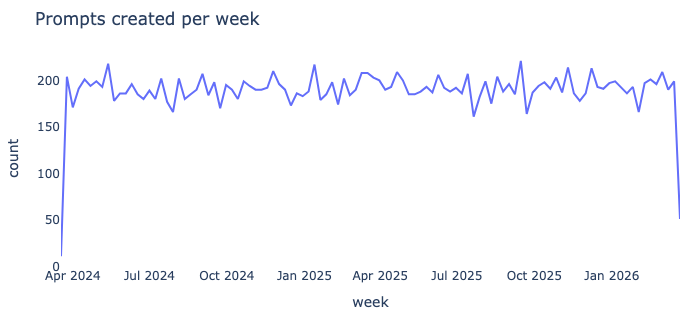

~189 prompts/week on average — creation rate is roughly flat over the sample.


In [11]:
weekly = (
    eda.dropna(subset=["created_at"])
    .assign(week=lambda x: x["created_at"].dt.to_period("W").dt.start_time)
    .groupby("week", as_index=False)
    .agg(prompts=("id", "count"))
)

fig = px.line(weekly, x="week", y="prompts",
              title="Prompts created per week",
              labels={"week": "week", "prompts": "count"})
apply_fig_layout(fig, FIG, height=320)
fig.show()

mean_wk = weekly["prompts"].mean()
print(f"~{mean_wk:.0f} prompts/week on average — creation rate is roughly flat over the sample.")

### 2. How concentrated is the corpus across categories?

**Observation.** Hundreds of distinct categories; the top 25 cover only about two-thirds of the corpus. The long tail is mostly single-digit niches. That is why raw global popularity would punish rare-but-relevant prompts — we will normalize engagement **per category** when we build the metadata scorer in Chapter 6.

distinct categories : 420
top-25 share        : 66.6%


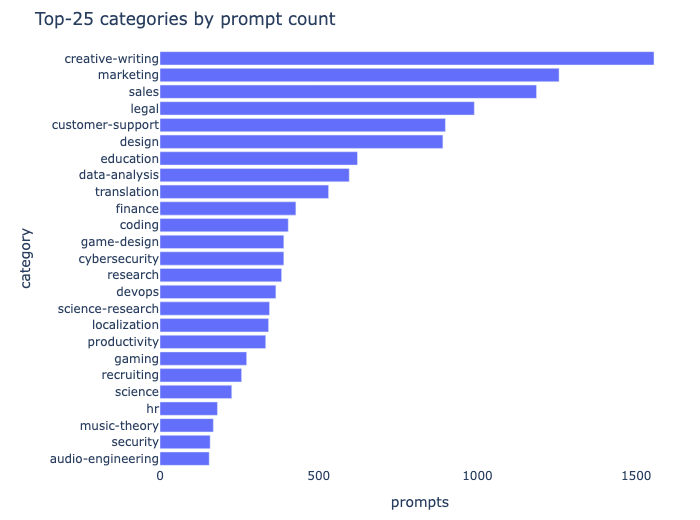

In [12]:
cat_counts = df["category"].value_counts()
total = len(df)
top25 = cat_counts.head(25)
print(f"distinct categories : {df['category'].nunique()}")
print(f"top-25 share        : {top25.sum() / total * 100:.1f}%")

top25_df = top25.iloc[::-1].reset_index()
top25_df.columns = ["category", "prompts"]
fig = px.bar(top25_df, y="category", x="prompts", orientation="h",
             title="Top-25 categories by prompt count",
             labels={"prompts": "prompts", "category": "category"})
apply_fig_layout(fig, FIG, height=520, margin=dict(l=160, r=20, t=50, b=40), showlegend=False)
fig.show()

### 3. Difficulty mix

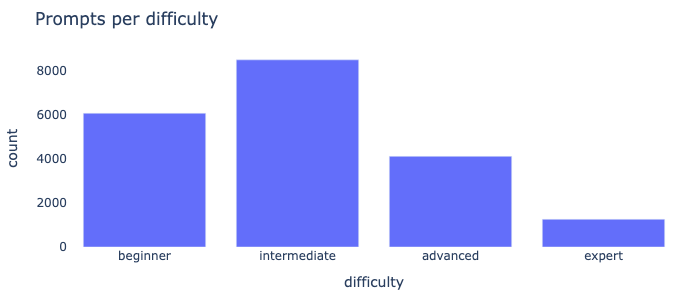

In [13]:
diff_order = ["beginner", "intermediate", "advanced", "expert"]
diff_counts = df["difficulty"].value_counts().reindex(diff_order)
fig = px.bar(diff_counts.reset_index(), x="difficulty", y="count",
             title="Prompts per difficulty",
             labels={"count": "count", "difficulty": "difficulty"})
apply_fig_layout(fig, FIG, height=300, showlegend=False)
fig.show()

### 4. Engagement, on the right scale

Likes, upvotes, views, uses and `fork_count` are all heavy-tailed — so we view them on a log scale. `log1p` keeps zeros visible.

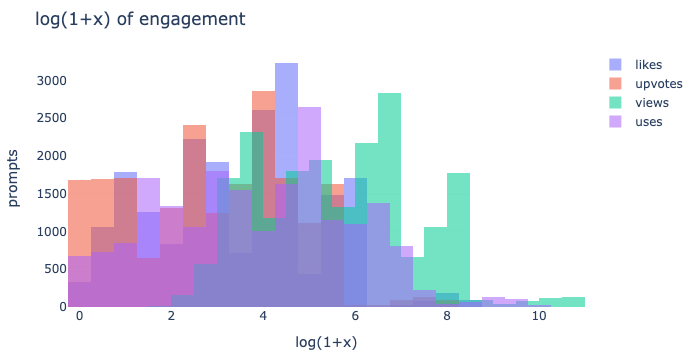

Median engagement (raw): ~39 likes, ~17 upvotes, ~281 views, ~51 uses


In [14]:
ENG_COLS = ["likes", "upvotes", "downvotes", "views", "uses", "fork_count"]
log_eng = df[ENG_COLS].apply(np.log1p)
log_eng.describe().round(2)

fig = go.Figure()
for col in ["likes", "upvotes", "views", "uses"]:
    fig.add_trace(go.Histogram(x=log_eng[col], name=col, opacity=0.55, nbinsx=40))
apply_fig_layout(
    fig,
    FIG,
    height=360,
    barmode="overlay",
    title="log(1+x) of engagement",
    xaxis_title="log(1+x)",
    yaxis_title="prompts",
)
fig.show()

med = df[ENG_COLS].median()
print(
    f"Median engagement (raw): ~{med['likes']:.0f} likes, ~{med['upvotes']:.0f} upvotes, "
    f"~{med['views']:.0f} views, ~{med['uses']:.0f} uses"
)

### 5. Are popular prompts actually useful?

Proxy "useful" with `uses / views` — a *use* is a more committed signal than a passive view.

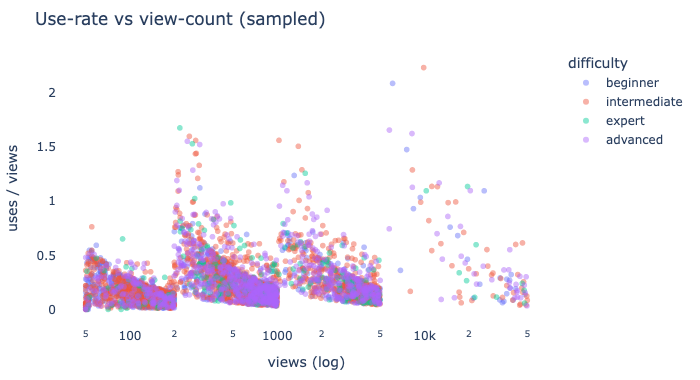

In [15]:
sub = df[df["views"] >= 50].copy()
sub["use_rate"] = sub["uses"] / sub["views"]
sample_n = min(4000, len(sub))
fig = px.scatter(
    sub.sample(sample_n, random_state=1729),
    x="views", y="use_rate", color="difficulty",
    log_x=True, opacity=0.45,
    title="Use-rate vs view-count (sampled)",
    labels={"views": "views (log)", "use_rate": "uses / views"},
)
apply_fig_layout(fig, FIG, height=380)
fig.show()

### 6. The `target_model` deep dive

The dataset has ten values in `target_model`: nine model-specific buckets plus `any` ("works on any model"). We look at volume, engagement, category mix, and difficulty mix — this metadata feeds the intent-aware fusion in **Chapters 6–7**.

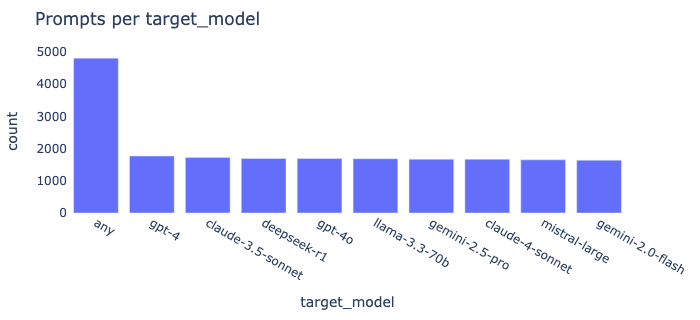

,likes,upvotes,views,uses
target_model,,,,
any,224.9,129.0,2091.5,564.8
gpt-4,136.2,79.1,1281.4,365.2
gemini-2.5-pro,125.7,75.3,1088.6,289.5
gpt-4o,121.4,71.7,1186.5,294.5
gemini-2.0-flash,115.2,69.8,1126.2,283.3
mistral-large,111.3,62.0,1102.3,292.6
deepseek-r1,108.5,62.4,1035.8,261.6
claude-3.5-sonnet,108.0,66.1,1033.1,245.0
llama-3.3-70b,98.0,53.4,1019.5,227.0


In [16]:
target_counts = df["target_model"].value_counts()
fig = px.bar(target_counts.reset_index(), x="target_model", y="count",
             title="Prompts per target_model",
             labels={"count": "count", "target_model": "target_model"})
apply_fig_layout(fig, FIG, height=320, showlegend=False)
fig.show()

target_eng = (
    df.groupby("target_model")[["likes", "upvotes", "views", "uses"]]
    .mean()
    .round(1)
    .sort_values("likes", ascending=False)
)
target_eng

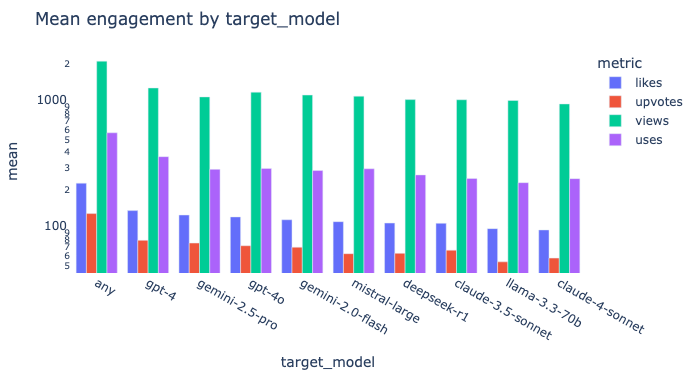

'any' mean likes: 225  vs  model-specific average: 113  (~2.0x)


In [17]:
fig = px.bar(
    target_eng.reset_index().melt(id_vars="target_model", var_name="metric", value_name="mean"),
    x="target_model", y="mean", color="metric", barmode="group",
    title="Mean engagement by target_model",
)
apply_fig_layout(fig, FIG, height=380)
fig.update_yaxes(type="log")
fig.show()

any_likes = target_eng.loc["any", "likes"] if "any" in target_eng.index else np.nan
model_mean = target_eng.drop(index="any", errors="ignore")["likes"].mean()
if pd.notna(any_likes) and model_mean:
    print(f"'any' mean likes: {any_likes:.0f}  vs  model-specific average: {model_mean:.0f}  (~{any_likes/model_mean:.1f}x)")

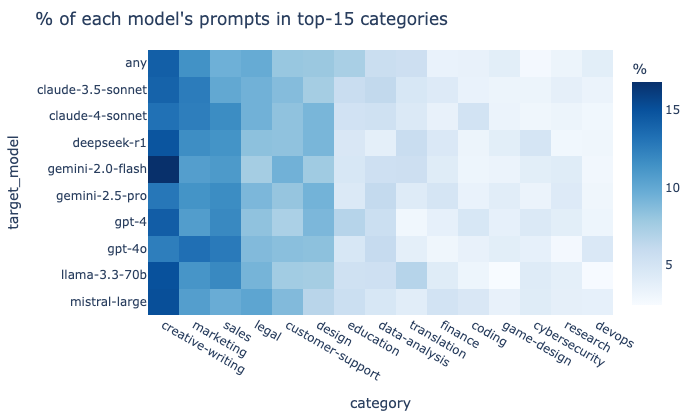

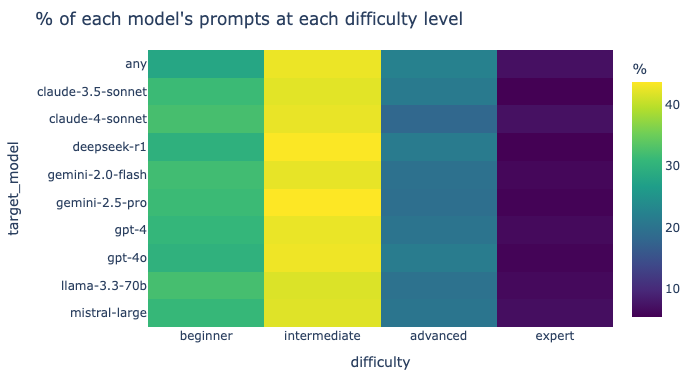

difficulty,beginner,intermediate,advanced,expert
target_model,,,,
any,28.1,42.7,22.2,7.0
claude-3.5-sonnet,31.4,42.1,21.1,5.4
claude-4-sonnet,32.3,42.5,18.1,7.1
deepseek-r1,29.8,43.6,21.2,5.4
gemini-2.0-flash,31.8,42.4,19.7,6.1
gemini-2.5-pro,31.4,43.7,19.3,5.6
gpt-4,30.7,42.6,20.2,6.4
gpt-4o,29.9,42.9,21.4,5.7
llama-3.3-70b,32.2,41.7,19.8,6.3


In [18]:
top_cats = df["category"].value_counts().head(15).index.tolist()
sub_tm = df[df["category"].isin(top_cats)]
ct = pd.crosstab(sub_tm["target_model"], sub_tm["category"], normalize="index").round(3) * 100
ct = ct[top_cats]

fig = px.imshow(
    ct, aspect="auto", color_continuous_scale="Blues",
    title="% of each model's prompts in top-15 categories",
    labels=dict(x="category", y="target_model", color="%"),
)
apply_fig_layout(fig, FIG, height=420, margin=dict(l=40, r=20, t=50, b=80))
fig.show()

ct_diff = pd.crosstab(df["target_model"], df["difficulty"], normalize="index").round(3) * 100
ct_diff = ct_diff[["beginner", "intermediate", "advanced", "expert"]]
fig = px.imshow(
    ct_diff, aspect="auto", color_continuous_scale="Viridis",
    title="% of each model's prompts at each difficulty level",
    labels=dict(x="difficulty", y="target_model", color="%"),
)
apply_fig_layout(fig, FIG, height=380)
fig.show()
ct_diff

### 7. How long are titles and bodies?

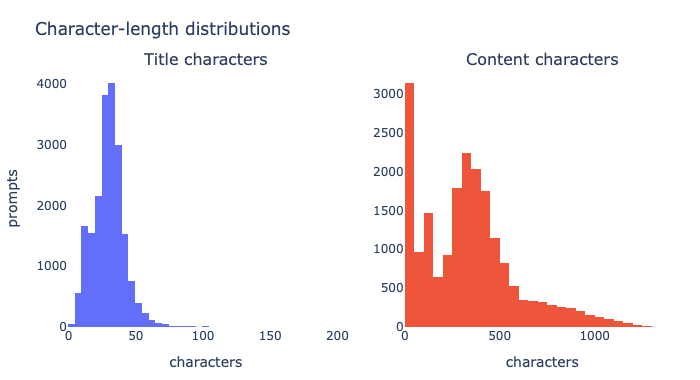

In [19]:
from plotly.subplots import make_subplots
df_len = pd.DataFrame({
    "title_chars": df["title"].str.len(),
    "content_chars": df["content"].str.len(),
})
df_len.describe(percentiles=[0.5, 0.9, 0.95, 0.99]).round(0)

fig = make_subplots(rows=1, cols=2, subplot_titles=("Title characters", "Content characters"))
fig.add_trace(go.Histogram(x=df_len["title_chars"], nbinsx=40, marker_color="#636efa", name="title"), row=1, col=1)
fig.add_trace(go.Histogram(x=df_len["content_chars"], nbinsx=40, marker_color="#ef553b", name="content"), row=1, col=2)
apply_fig_layout(
    fig,
    FIG,
    height=380,
    showlegend=False,
    title_text="Character-length distributions",
    margin=dict(l=40, r=20, t=70, b=40),
)
fig.update_xaxes(title_text="characters", row=1, col=1)
fig.update_xaxes(title_text="characters", row=1, col=2)
fig.update_yaxes(title_text="prompts", row=1, col=1)
fig.show()

### 8. Tags — another long tail

In [20]:
all_tags = [t for tags in df["tags"] for t in tags]
tag_counts = pd.Series(all_tags).value_counts()
print(f"total tag tokens   : {len(all_tags):,}")
print(f"unique tags        : {tag_counts.size:,}")
print(f"top-30 share       : {tag_counts.head(30).sum() / len(all_tags) * 100:.1f}%")
tag_counts.head(15)

total tag tokens   : 83,066
unique tags        : 16,686
top-30 share       : 8.9%


template          469
beginner          409
compliance        352
writing           332
documentation     328
feedback          323
analysis          309
email             293
python            253
small-business    239
dialogue          237
automation        232
marketing         228
branding          228
communication     223
Name: count, dtype: int64

### 9. A few more checks

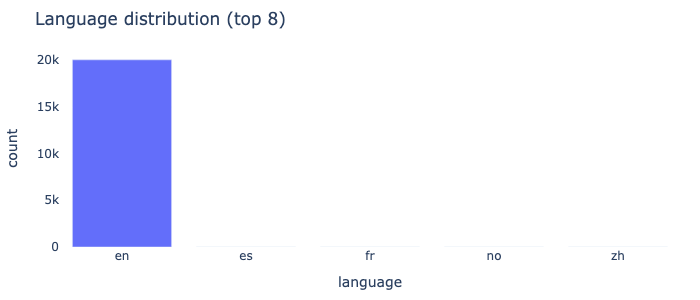

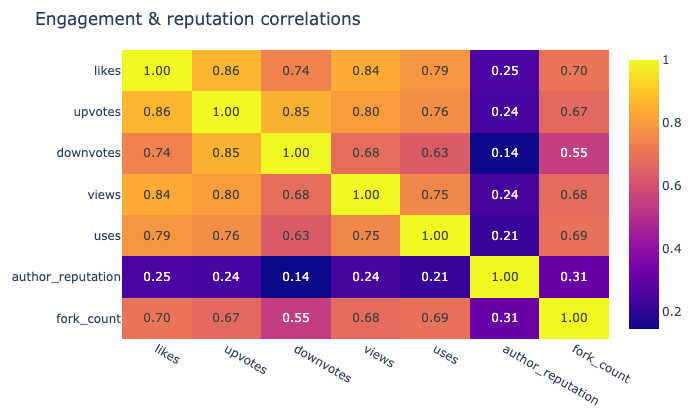

In [21]:
# Language — almost everything is English; embeddings are still English-tuned MiniLM.
lang = df["language"].value_counts().head(8).reset_index()
lang.columns = ["language", "count"]
fig = px.bar(lang, x="language", y="count", title="Language distribution (top 8)")
apply_fig_layout(fig, FIG, height=300)
fig.show()

# Metadata correlations — likes/upvotes/views move together but are not identical.
corr_cols = ["likes", "upvotes", "downvotes", "views", "uses", "author_reputation", "fork_count"]
corr = df[corr_cols].corr()
fig = px.imshow(corr, text_auto=".2f", aspect="auto", title="Engagement & reputation correlations")
apply_fig_layout(fig, FIG, height=420)
fig.show()

### Takeaways we will use later

| Finding | Consequence in *this* notebook |
|---|---|
| Corpus grows at ~constant rate week to week — recency is not encoded in volume. | **Ch. 6:** explicit freshness decay (180-day half-life). |
| **`any` prompts carry a higher engagement halo** than model-specific ones. | **Ch. 6–7:** modest popularity weight + **target-compatibility** when the query names a model. |
| **Hundreds of categories**; top-25 ≈ two-thirds of rows; tags are an even longer tail. | **Ch. 3:** rich `semantic_text` (title + category + tags + body). **Ch. 5:** BM25 for rare lexical hooks. **Ch. 6:** blend several log-scaled signals, not one raw counter. |
| Difficulty mix is similar across targets; category×target patterns are weak. | **Ch. 7:** detect target intent from the **query**, not from the candidate's metadata alone. |
| Titles are short; content is bimodal (stubs vs long prompts). | **Ch. 3–4:** composite text + truncation later; **Ch. 6:** cross-encoder reads full pairs for top-*k*. |
| `log1p` engagement is near-Gaussian; high views ≠ high use-rate. | **Ch. 6:** never rank on views alone; downvote dampener + multi-signal popularity. |
| PCA shows visible category neighborhoods. | **Ch. 4–5:** dense retrieval is viable; hybrid fusion is worth the complexity. |

## Chapter 3 — Teaching the machine to read

This is the first step the LEAF brief describes: turn each prompt into something an embedding model can actually consume.

Our first attempt was simply `embed(content)`, the body of the prompt. It looked clean. It also lost a lot of useful information. A short user query like *"linkedin post for product launch"* was failing to surface obviously-relevant prompts whose category and tags screamed "marketing" but whose body never used the word "linkedin". The model had no way to know that, because we had hidden the metadata.

So we designed a single composite field — call it `semantic_text` — that the embedding model sees per prompt:

- **Title** — compact intent, often the cleanest summary of what the prompt is for.
- **Category & subcategory** — the platform's own taxonomy, surprisingly informative for short queries.
- **Tags** — keyword-level hints (`["nodejs", "performance", "debugging"]`) that act as a soft index.
- **Content** — the actual prompt body, the core meaning.

We also tokenize this same field for BM25 later, so dense and lexical retrievers see *the same view* of each prompt. That fairness will matter when we benchmark them against each other in the next chapter.

In [22]:
def safe_text(x):
    if isinstance(x, list):
        return " ".join(map(str, x))
    if pd.isna(x):
        return ""
    return str(x)

work = df.copy()
work["semantic_text"] = (
    "Title: " + work["title"].map(safe_text) + "\n"
    + "Category: " + work["category"].map(safe_text) + "\n"
    + "Subcategory: " + work["subcategory"].map(safe_text) + "\n"
    + "Tags: " + work["tags"].map(safe_text) + "\n"
    + "Prompt: " + work["content"].map(safe_text)
)

work["tokenized_for_bm25"] = work["semantic_text"].str.lower().str.findall(r"\b\w+\b")
work[["id", "title", "semantic_text"]].head(2)

,id,title,semantic_text
0,pk_03138,Complete Brand Identity Brief,Title: Complete Brand Identity Brief\nCategory...
1,pk_07711,Balance Turn-Based Combat Stats,Title: Balance Turn-Based Combat Stats\nCatego...


## Chapter 4 — Building the library

Now we move from "vector-ready text" to actual vectors. The *vector database* step. In our setup FAISS is the database: it owns the vectors and the nearest-neighbor index, while pandas keeps owning the metadata. Two homes, one `id` column linking them — simple and easy to debug.

We deliberately stay on **pretrained, open-source models**, as the LEAF brief encouraged. 

The trio we settled on:

- **Embedding model** — `sentence-transformers/all-MiniLM-L6-v2`. 384-dim vectors, ~80MB, surprisingly competitive on retrieval tasks for its size, and fast enough to embed the entire dataset on a laptop. This connects directly to Prof. Alessio's classes (vector semantics and sentence transformers).
- **Reranker model** (used later, in Chapter 6) — `cross-encoder/ms-marco-MiniLM-L-6-v2`. A cross-encoder reads the query and a candidate *together*, so it can pick up word-level alignment that bi-encoder cosine cannot. This is the **retrieve-then-rerank** pattern from another covered in class topic (RAG).
- **Vector index** — FAISS' `IndexFlatIP` over L2-normalized vectors. Inner product on normalized vectors is mathematically cosine similarity, but FAISS makes it fast. We also kept a `sklearn.NearestNeighbors` fallback so the notebook runs cleanly on machines where FAISS-CPU did not install.

The first run of this cell is slow; every run after that is nearly instant — see the next note about caching.

After indexing we plot a **2D PCA semantic map** (sampled prompts) in the next subsection — exported to `assets/semantic_map_pca.png`.


In [23]:
import torch
from sentence_transformers import SentenceTransformer

print("CUDA:", torch.cuda.is_available())
print("MPS:", torch.backends.mps.is_available() if hasattr(torch.backends, "mps") else False)

device = "cuda" if torch.cuda.is_available() else ("mps" if hasattr(torch.backends, "mps") and torch.backends.mps.is_available() else "cpu")
print("Chosen device:", device)

EMBED_MODEL_NAME = "sentence-transformers/all-MiniLM-L6-v2"
embedder = SentenceTransformer(EMBED_MODEL_NAME, device=device)

print("Model device:", embedder.device)

CUDA: False
MPS: True
Chosen device: mps


Model device: mps:0


In [24]:
EMBED_MODEL_NAME = "sentence-transformers/all-MiniLM-L6-v2"
RE_RANKER_NAME = "cross-encoder/ms-marco-MiniLM-L-6-v2"

CANDIDATE_EMBED_MODELS = [
    "sentence-transformers/all-MiniLM-L6-v2",
    "BAAI/bge-small-en-v1.5",
    "intfloat/e5-small-v2",
]

import torch
from pathlib import Path

device = "cuda" if torch.cuda.is_available() else (
    "mps" if hasattr(torch.backends, "mps") and torch.backends.mps.is_available() else "cpu"
)

def _cache_name(model_name, max_chars=700):
    safe = model_name.replace('/', '__').replace('-', '_')
    return Path(f"emb_cache_{safe}_{max_chars}.npy")

def build_embedding_index(model_name, semantic_texts, max_chars=700, batch_size=64):
    emb_model = SentenceTransformer(model_name, device=device)
    cache_path = _cache_name(model_name, max_chars)

    if cache_path.exists():
        arr = np.load(cache_path)
    else:
        corpus_fast = [t[:max_chars] for t in semantic_texts]
        arr = emb_model.encode(
            corpus_fast,
            batch_size=batch_size,
            show_progress_bar=True,
            normalize_embeddings=True,
        )
        arr = np.asarray(arr, dtype=np.float32)
        np.save(cache_path, arr)

    use_faiss_local = True
    try:
        import faiss
        idx = faiss.IndexFlatIP(arr.shape[1])
        idx.add(arr)
    except Exception:
        use_faiss_local = False
        idx = NearestNeighbors(n_neighbors=100, metric="cosine")
        idx.fit(arr)

    return emb_model, arr, idx, use_faiss_local

embedder, emb, index, use_faiss = build_embedding_index(
    EMBED_MODEL_NAME,
    work["semantic_text"].tolist(),
    max_chars=700,
    batch_size=64,
)

print("Device:", device)
print("Embeddings shape:", emb.shape)
print("Using FAISS:", use_faiss)
print("Active embedding model:", EMBED_MODEL_NAME)


Device: mps
Embeddings shape: (20000, 384)
Using FAISS: True
Active embedding model: sentence-transformers/all-MiniLM-L6-v2


### Semantic map (PCA of embeddings)

After building the FAISS index we project a sample of prompt vectors to 2D with PCA. **Color = category** shows whether neighborhoods align with taxonomy; the second chart colors by **`target_model`** so we can see if model-specific prompts cluster separately from `any`.


In [ ]:

PCA_SAMPLE = 2500
_pca_idx = np.random.RandomState(1729).choice(len(work), size=min(PCA_SAMPLE, len(work)), replace=False)
_pca_emb = emb[_pca_idx]
_pca_xy = PCA(n_components=2, random_state=1729).fit_transform(_pca_emb)

pca_df = work.iloc[_pca_idx][["id", "title", "category", "target_model"]].reset_index(drop=True)
pca_df["pc1"] = _pca_xy[:, 0]
pca_df["pc2"] = _pca_xy[:, 1]

fig_pca = px.scatter(
    pca_df,
    x="pc1",
    y="pc2",
    color="category",
    hover_data=["title", "target_model"],
    title=f"Semantic map — PCA of {len(pca_df):,} prompt embeddings",
    labels={"pc1": "PC1", "pc2": "PC2"},
)
apply_fig_layout(fig_pca, FIG, height=480)
save_show(fig_pca, "semantic_map_pca.png", width=920, height=480)

fig_pca_tm = px.scatter(
    pca_df,
    x="pc1",
    y="pc2",
    color="target_model",
    hover_data=["title", "category"],
    title="Same PCA — colored by target_model",
    labels={"pc1": "PC1", "pc2": "PC2"},
)
apply_fig_layout(fig_pca_tm, FIG, height=480)
save_show(fig_pca_tm, "semantic_map_pca_by_target_model.png", width=920, height=480)


#### A small horror story: the embedding loop that wouldn't end

The first time we tried to embed the whole dataset, things went badly. After ~96 minutes the progress bar still read about 12%. We were embedding the full `semantic_text` for every prompt on a CPU-only PyTorch build, with default batch size, without any caching, and without truncating the long ones.

Four fixes, applied in order, made the problem disappear:

1. **Hardware acceleration first.** The notebook now picks the best available device automatically: CUDA on a real GPU, Apple `mps` on M-series Macs, CPU as a last resort. 
2. **Truncate aggressively before embedding.** We cap each `semantic_text` at 700 characters. The retrieval signal lives in the title, tags, category, and the first part of the content — a 5,000-character body of boilerplate adds noise more than meaning.
3. **Tune the batch size**. Starting from 64 gave us stable throughput on every machine we tested, without spilling memory.
4. **Cache the embeddings to disk** (`emb_cache_<model>_<max_chars>.npy`). The first run pays the full cost; every subsequent run starts in seconds. This also means our model-comparison chapter is realistic to run multiple times instead of one heroic overnight session.

### Auditioning more brains

MiniLM is the safe pick, and it is the one we develop the rest of the pipeline against. But the LEAF brief explicitly listed a few other open-source embedding models worth testing — and so we lined up a small audition.

The candidates:

- `sentence-transformers/all-MiniLM-L6-v2` — our incumbent baseline, fast and well-known.
- `BAAI/bge-small-en-v1.5` — strong quality-to-size ratio, often ranks near the top of MTEB benchmarks.
- `intfloat/e5-small-v2` — another lightweight, retrieval-tuned model, also recommended in the brief.

Same dataset, same `semantic_text`, same FAISS index, same evaluation queries. The benchmark cell in **Chapter 8** is what actually decides which of them powers the active pipeline. We are deliberately not picking based on intuition.


## Chapter 5 — The first search

Now the system actually does something. A user types a query, we embed it with the *same* model the dataset was embedded with, FAISS returns the nearest neighbors, and we read off the top results. That is the literal Step 3 from the brief.

Dense embeddings are great at *meaning* but they sometimes miss exact tokens — a model name, a library, a niche acronym — that a user typed for a reason. So we kept a **BM25** lexical retriever alongside the dense one, sharing the same tokenized view of `semantic_text` we built in Chapter 3. Now the user has two flashlights pointing at the same library, each catching things the other one misses.

Three retrieval functions live in the next cell:

- `retrieve_dense` — the canonical cosine-similarity path. We use FAISS inner product on L2-normalized vectors, which is equivalent to cosine.
- `retrieve_bm25` — pure lexical scoring, fast and surprisingly competitive on keyword-heavy queries.
- `retrieve_hybrid` — our small creative move: min-max normalize both score lists onto `[0, 1]` and blend with a tunable `alpha`. That single knob, set to ~0.65 in favor of the dense side, was the cheapest quality boost we found in the whole project.

In [25]:
bm25 = BM25Okapi(work["tokenized_for_bm25"].tolist())


def _normalize_scores(vals):
    vals = np.asarray(vals, dtype=float)
    if len(vals) == 0:
        return vals
    vmin, vmax = vals.min(), vals.max()
    if np.isclose(vmin, vmax):
        return np.ones_like(vals)
    return (vals - vmin) / (vmax - vmin)


def retrieve_dense(query, top_k=20):
    qvec = embedder.encode([query], normalize_embeddings=True)
    qvec = np.asarray(qvec, dtype=np.float32)

    if use_faiss:
        sims, idxs = index.search(qvec, top_k)
        sims, idxs = sims[0], idxs[0]
    else:
        dists, idxs = index.kneighbors(qvec, n_neighbors=top_k)
        sims, idxs = 1 - dists[0], idxs[0]

    out = work.iloc[idxs].copy()
    out["dense_score"] = sims
    return out.reset_index(drop=True)


def retrieve_bm25(query, top_k=20):
    toks = re.findall(r"\b\w+\b", query.lower())
    scores = bm25.get_scores(toks)
    idxs = np.argsort(scores)[::-1][:top_k]
    out = work.iloc[idxs].copy()
    out["bm25_score"] = scores[idxs]
    return out.reset_index(drop=True)


def retrieve_hybrid(query, top_k=20, alpha=0.65):
    # alpha => weight for dense retrieval
    d = retrieve_dense(query, top_k=top_k * 4)[["id", "title", "semantic_text", "dense_score"]]
    b = retrieve_bm25(query, top_k=top_k * 4)[["id", "bm25_score"]]

    m = d.merge(b, on="id", how="outer").fillna(0)
    m["dense_n"] = _normalize_scores(m["dense_score"].values)
    m["bm25_n"] = _normalize_scores(m["bm25_score"].values)
    m["hybrid_score"] = alpha * m["dense_n"] + (1 - alpha) * m["bm25_n"]

    m = m.sort_values("hybrid_score", ascending=False).head(top_k)
    out = m.merge(work, on="id", how="left", suffixes=("", "_full"))
    return out.reset_index(drop=True)

## Chapter 6 — A second opinion, then a popularity check

Hybrid retrieval gives us a strong first pass, but cosine similarity is, fundamentally, an *approximation* — a thumbnail comparison. Two prompts can have similar vectors and still mean different things in context. This is exactly the gap a **cross-encoder reranker** is designed to close: it takes the query and a single candidate as a *pair*, runs them together through a deeper model, and outputs a relevance score that has actually read both texts at once.

This is the **retrieve-then-rerank** pattern. Stage 1 (FAISS + BM25 hybrid) is cheap and runs over the full dataset. Stage 2 (the cross-encoder, `cross-encoder/ms-marco-MiniLM-L-6-v2`) is more expensive per pair, but only sees the top ~50–100 survivors. The combined latency stays comfortable.

Then we go beyond what cosine *or* a reranker could ever know — and into the **bonus** that LEAF specifically called out for "extra points": **metadata-aware ranking**.

A prompt with 5,000 likes and a 9.5 author reputation is very probably better than an obscure one with the same semantics. Equivalent to *Google PageRank meets vector search*. Our final score blends four ingredients:

- **Semantic relevance** (the cross-encoder score, normalized) — does this prompt actually match the question?
- **Popularity** — a weighted blend of likes, upvotes, views, and uses, all normalized.
- **Quality proxy** — author reputation, fork count, and version count: the prompt has been validated, copied, refined.
- **Freshness** — an exponential decay over `created_at`, so a 2-week-old answer beats a 2-year-old one when both look equally relevant.

The exact mixing weights are are *tuned* on validation queries in Chapter 9.

### Two small ideas with surprisingly large effects

While we were inspecting failure cases, two small ideas kept coming up. Both are switchable, so we can A/B them honestly later.

**1. Intent-adaptive weighting.** A coding query and a marketing query do not benefit from the same recipe. For *"debug a slow Python API endpoint"* we want raw semantic precision — the right answer either matches the technical intent or it doesn't, and a wildly popular but irrelevant marketing prompt would be worse than no result at all. For *"write a LinkedIn post for product launch"*, on the other hand, popularity *is* signal — a copy template that thousands of people upvoted is genuinely useful. So we wrote a small `detect_query_intent` heuristic that classifies queries into `coding`, `marketing`, `data-analysis`, `creative-writing`, or `general`, and chooses the metadata weights accordingly.

**2. MMR diversification.** Especially with a strong reranker, we noticed the top 5 results would sometimes be near-duplicates of each other — same prompt at versions 1, 2, 3. Useless to a user. **Maximal Marginal Relevance** is the classic trick: at each step, pick the next result that maximizes a balance of *(a)* relevance and *(b)* dissimilarity to what is already on the page. With `lambda_rel = 0.82` we kept relevance dominant but avoided the near-duplicate problem.

Both knobs live in the unified `search_pipeline` and can be turned on or off at call time. We use that same flexibility in the next chapter to measure how much they actually help.


In [26]:

# Query-aware metadata: users often name an LLM ("for Claude", "with GPT-4o").
TARGET_MODEL_ALIASES = {
    "gpt-4o": ["gpt-4o", "gpt4o", "gpt 4o", "chatgpt-4o", "openai gpt-4o"],
    "gpt-4": ["gpt-4", "gpt4", "gpt 4", "chatgpt-4", "chatgpt"],
    "claude-3.5-sonnet": ["claude 3.5", "claude-3.5", "claude 3.5 sonnet", "claude sonnet"],
    "claude-4-sonnet": ["claude 4", "claude-4", "claude 4 sonnet", "claude opus"],
    "gemini-2.0-flash": ["gemini 2.0", "gemini-2.0", "gemini flash", "gemini 2.0 flash"],
    "gemini-2.5-pro": ["gemini 2.5", "gemini-2.5", "gemini pro", "gemini 2.5 pro"],
    "llama-3.3-70b": ["llama 3.3", "llama-3.3", "llama 70b", "llama 3"],
    "deepseek-r1": ["deepseek", "deepseek r1", "deepseek-r1"],
    "mistral-large": ["mistral large", "mistral-large", "mistral ai"],
}


def detect_target_model(query: str):
    if not query:
        return None
    q = query.lower().replace("_", " ")
    for canonical, aliases in TARGET_MODEL_ALIASES.items():
        for alias in sorted(aliases, key=len, reverse=True):
            if alias in q:
                return canonical
    for slug in TARGET_MODEL_ALIASES:
        if slug.replace("-", " ") in q or slug in q.replace(" ", "-"):
            return slug
    if any(p in q for p in ["any model", "any llm", "model agnostic", "any provider"]):
        return "any"
    return None


def detect_difficulty_hint(query: str):
    q = (query or "").lower()
    if any(k in q for k in ["beginner", "simple", "non-expert", "eli5", "5 year old", "kids", "novice"]):
        return "beginner"
    if any(k in q for k in ["advanced", "expert", "senior", "production-grade"]):
        return "advanced"
    return None


def detect_query_language(query: str):
    q = (query or "").lower()
    if any(k in q for k in ["español", "spanish", " en espanol", " en español"]):
        return "es"
    if any(k in q for k in ["français", "french", " en français"]):
        return "fr"
    if any(k in q for k in ["deutsch", "german"]):
        return "de"
    return None


def target_model_compat_score(candidate_tm, requested_tm):
    if requested_tm is None:
        return 1.0
    c = str(candidate_tm or "any")
    if c == requested_tm:
        return 1.0
    if c == "any":
        return 0.90
    if requested_tm == "any":
        return 1.0
    return 0.50


def difficulty_compat_score(candidate_diff, hint):
    if hint is None:
        return 1.0
    c = str(candidate_diff or "")
    if c == hint:
        return 1.0
    if hint == "beginner" and c == "intermediate":
        return 0.85
    return 0.75


def language_compat_score(candidate_lang, hint):
    if hint is None:
        return 1.0
    return 1.0 if str(candidate_lang or "en") == hint else 0.80


def detect_query_intent(query: str):
    q = query.lower()
    if any(k in q for k in ["code", "python", "api", "debug", "bug", "sql"]):
        return "coding"
    if any(k in q for k in ["email", "campaign", "ad", "brand", "linkedin", "seo", "marketing"]):
        return "marketing"
    if any(k in q for k in ["analysis", "dashboard", "kpi", "forecast", "trend", "data"]):
        return "data-analysis"
    if any(k in q for k in ["story", "poem", "creative", "script", "fiction"]):
        return "creative-writing"
    return "general"


def intent_adaptive_weights(intent):
    if intent == "marketing":
        return dict(w_sem=0.64, w_pop=0.20, w_quality=0.10, w_fresh=0.06)
    if intent == "coding":
        return dict(w_sem=0.78, w_pop=0.10, w_quality=0.09, w_fresh=0.03)
    if intent == "data-analysis":
        return dict(w_sem=0.74, w_pop=0.12, w_quality=0.10, w_fresh=0.04)
    if intent == "creative-writing":
        return dict(w_sem=0.70, w_pop=0.14, w_quality=0.08, w_fresh=0.08)
    return dict(w_sem=0.72, w_pop=0.14, w_quality=0.09, w_fresh=0.05)


def mmr_diversify(df_in, lambda_rel=0.80, top_k=10):
    if len(df_in) <= top_k:
        return df_in.copy()

    cand = df_in.copy().reset_index(drop=True)
    vecs = embedder.encode(cand["semantic_text"].tolist(), normalize_embeddings=True, show_progress_bar=False)
    vecs = np.asarray(vecs)

    selected = [0]
    remaining = set(range(1, len(cand)))
    rel = _normalize_scores(cand["final_score"].values)

    while len(selected) < min(top_k, len(cand)) and remaining:
        best_i, best_val = None, -1e9
        for i in list(remaining):
            sim_to_sel = max(np.dot(vecs[i], vecs[j]) for j in selected)
            mmr = lambda_rel * rel[i] - (1 - lambda_rel) * sim_to_sel
            if mmr > best_val:
                best_i, best_val = i, mmr
        selected.append(best_i)
        remaining.remove(best_i)

    out = cand.iloc[selected].copy()
    out["mmr_rank"] = range(1, len(out) + 1)
    return out.reset_index(drop=True)

In [27]:
reranker = CrossEncoder(RE_RANKER_NAME)


meta_cols = ["likes", "upvotes", "views", "uses", "author_reputation", "fork_count", "version"]
meta_df = work[meta_cols].fillna(0).copy()
meta_scaled = pd.DataFrame(MinMaxScaler().fit_transform(meta_df), columns=meta_cols)

work_meta = work.copy()
for c in meta_cols:
    work_meta[f"{c}_n"] = meta_scaled[c]

work_meta["created_at"] = pd.to_datetime(work_meta["created_at"], errors="coerce", utc=True)
max_dt = work_meta["created_at"].max()
work_meta["age_days"] = (max_dt - work_meta["created_at"]).dt.total_seconds() / 86400
work_meta["age_days"] = work_meta["age_days"].fillna(work_meta["age_days"].median())
work_meta["freshness"] = np.exp(-work_meta["age_days"] / 180.0)


def rerank(query, candidates_df, top_k=20):
    pairs = [(query, txt) for txt in candidates_df["semantic_text"].tolist()]
    rr_scores = reranker.predict(pairs)
    out = candidates_df.copy()
    out["rerank_score"] = rr_scores
    out = out.sort_values("rerank_score", ascending=False).head(top_k)
    return out.reset_index(drop=True)



DEFAULT_METADATA_WEIGHTS = dict(w_sem=0.72, w_pop=0.14, w_quality=0.09, w_fresh=0.05)
METADATA_WEIGHTS = DEFAULT_METADATA_WEIGHTS.copy()


def add_metadata_score(
    df_in,
    query=None,
    target_model_hint=None,
    difficulty_hint=None,
    language_hint=None,
    w_sem=None,
    w_pop=None,
    w_quality=None,
    w_fresh=None,
):
    """Blend semantic + popularity + quality + freshness; optional query-aware boosts."""
    weights = dict(METADATA_WEIGHTS)
    if w_sem is not None:
        weights.update(dict(w_sem=w_sem, w_pop=w_pop, w_quality=w_quality, w_fresh=w_fresh))

    _meta_cols = [
        "likes_n", "upvotes_n", "views_n", "uses_n",
        "author_reputation_n", "fork_count_n", "version_n", "freshness",
        "target_model", "difficulty", "language",
    ]
    merge_cols = ["id"] + [c for c in _meta_cols if c not in df_in.columns]
    if len(merge_cols) > 1:
        out = df_in.merge(work_meta[merge_cols], on="id", how="left")
    else:
        out = df_in.copy()

    def _col(df, name):
        if name in df.columns:
            return df[name]
        for suffix in ("_y", "_x", "_meta"):
            alt = f"{name}{suffix}"
            if alt in df.columns:
                return df[alt]
        return df_in[name] if name in df_in.columns else work_meta.set_index("id").loc[df["id"], name].values

    out["popularity"] = (
        0.45 * out["likes_n"]
        + 0.30 * out["upvotes_n"]
        + 0.15 * out["views_n"]
        + 0.10 * out["uses_n"]
    )
    out["quality"] = (
        0.6 * out["author_reputation_n"]
        + 0.25 * out["fork_count_n"]
        + 0.15 * out["version_n"]
    )

    sem = _normalize_scores(
        out["rerank_score"].values if "rerank_score" in out.columns else out["dense_score"].values
    )
    out["semantic_n"] = sem

    tm_hint = target_model_hint if target_model_hint is not None else detect_target_model(query)
    diff_hint = difficulty_hint if difficulty_hint is not None else detect_difficulty_hint(query)
    lang_hint = language_hint if language_hint is not None else detect_query_language(query)

    out["target_compat"] = [target_model_compat_score(tm, tm_hint) for tm in _col(out, "target_model")]
    out["difficulty_compat"] = [difficulty_compat_score(d, diff_hint) for d in _col(out, "difficulty")]
    out["language_compat"] = [language_compat_score(lang, lang_hint) for lang in _col(out, "language")]
    out["constraint_mult"] = out["target_compat"] * out["difficulty_compat"] * out["language_compat"]

    w_sem, w_pop, w_quality, w_fresh = (
        weights["w_sem"], weights["w_pop"], weights["w_quality"], weights["w_fresh"],
    )
    out["final_score"] = (
        w_sem * out["semantic_n"]
        + w_pop * out["popularity"]
        + w_quality * out["quality"]
        + w_fresh * out["freshness"]
    ) * out["constraint_mult"]

    out["query_target_model"] = tm_hint
    out["query_difficulty_hint"] = diff_hint
    out["query_language_hint"] = lang_hint
    out = out.sort_values("final_score", ascending=False)
    return out.reset_index(drop=True)

def search_pipeline(query, top_k=10, mode="hybrid"):
    t0 = time.perf_counter()

    if mode == "dense":
        stage1 = retrieve_dense(query, top_k=max(50, top_k * 5))
    elif mode == "bm25":
        stage1 = retrieve_bm25(query, top_k=max(50, top_k * 5))
        stage1 = stage1.merge(work[["id", "semantic_text"]], on="id", how="left")
    else:
        stage1 = retrieve_hybrid(query, top_k=max(50, top_k * 5))

    stage2 = rerank(query, stage1, top_k=max(30, top_k * 3))
    stage3 = add_metadata_score(stage2).head(top_k)

    t1 = time.perf_counter()
    latency_ms = (t1 - t0) * 1000

    return stage3, latency_ms

In [28]:
# Override pipeline AFTER base functions are defined above
# default settings prioritize precision
def search_pipeline(query, top_k=10, mode="hybrid", adaptive=False, diversify=False):
    t0 = time.perf_counter()

    if mode == "dense":
        stage1 = retrieve_dense(query, top_k=max(60, top_k * 6))
    elif mode == "bm25":
        stage1 = retrieve_bm25(query, top_k=max(60, top_k * 6))
        stage1 = stage1.merge(work[["id", "semantic_text"]], on="id", how="left")
    else:
        stage1 = retrieve_hybrid(query, top_k=max(60, top_k * 6))

    stage2 = rerank(query, stage1, top_k=max(40, top_k * 4))

    intent = detect_query_intent(query)
    if adaptive:
        stage3 = add_metadata_score(stage2, query=query, **intent_adaptive_weights(intent))
    else:
        stage3 = add_metadata_score(stage2, query=query)

    stage3["query_intent"] = intent

    if diversify:
        out = mmr_diversify(stage3, lambda_rel=0.82, top_k=top_k)
    else:
        out = stage3.head(top_k).reset_index(drop=True)

    latency_ms = (time.perf_counter() - t0) * 1000
    return out, latency_ms


## Chapter 7 — A first end-to-end run

This is the moment we wanted: one natural-language query goes in, one ranked, decorated table comes out — through every step we have built so far. We pick the cold-email query because it is the kind of prompt PromptKaban users would *actually* search for at work.

We deliberately surface every score column (`final_score`, `rerank_score`, `popularity`, `quality`, `freshness`) instead of hiding them behind one number. When a result looks weird, we want to immediately see *why*: was it the cross-encoder, the popularity boost, or the freshness decay that pushed it to the top? This transparency is also what we will lean on during the demo to convince a viewer that the ranking is not a black box.

In [29]:
query = "write a professional cold email to a potential B2B client"
results, latency_ms = search_pipeline(query, top_k=10, mode="hybrid")

print(f"Query: {query}")
print(f"Latency: {latency_ms:.2f} ms")

print("Detected target_model:", detect_target_model(query))

show_cols = [
    "id", "title", "category", "target_model", "language", "final_score", "rerank_score",
    "popularity", "quality", "freshness", "likes", "upvotes", "views"
]

results[show_cols]

Query: write a professional cold email to a potential B2B client
Latency: 1039.60 ms


,id,title,category,language,final_score,rerank_score,popularity,quality,freshness,likes,upvotes,views
0,pk_00096,Cold outreach email template,communication,en,0.811547,7.921940,0.002773,0.484877,0.950388,12,12,155
1,pk_16391,Write cold emails for B2B lead generation,marketing,en,0.558431,6.416883,0.013245,0.264499,0.100973,87,32,649
2,pk_06705,Write Outreach Emails for {{industry}},marketing,en,0.524413,5.966787,0.039629,0.471938,0.123371,150,93,3956
3,pk_17635,cold emails that dont suck lol,marketing,en,0.515283,6.145596,0.000224,0.221739,0.044607,1,1,13
4,pk_06523,so i need to write like an email to potential ...,sales,en,0.512072,5.899022,0.001988,0.379622,0.321270,9,9,79
5,pk_01929,Cold outreach email template,cold-outreach,en,0.473935,5.368376,0.068154,0.508859,0.496481,343,249,2454
6,pk_03868,Cold outreach email for SaaS product,communication,en,0.456041,5.222217,0.001702,0.436957,0.827543,7,7,122
7,pk_02405,Cold outreach email template,sales,en,0.435350,5.393816,0.008009,0.379168,0.061631,46,15,684
8,pk_12163,Cold outreach email template,outreach,en,0.421109,5.185318,0.007672,0.487600,0.115293,34,21,342
9,pk_13179,Personalized cold email template,sales,en,0.407712,5.295845,0.018428,0.105255,0.223058,81,75,821


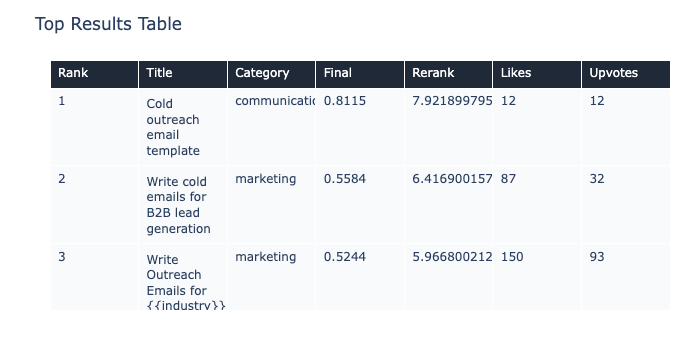

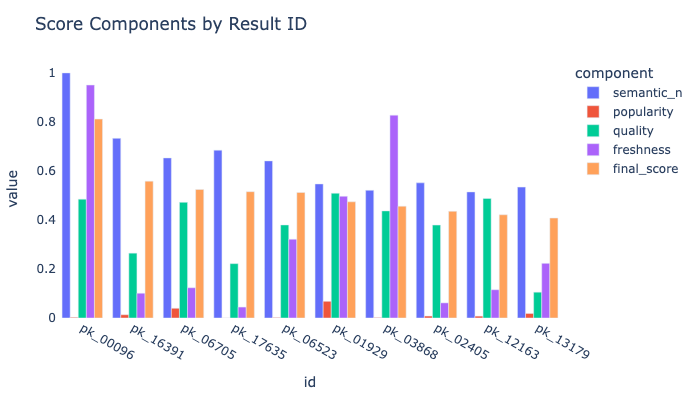

In [30]:
viz = results.copy()
fig_table = go.Figure(data=[go.Table(
    header=dict(values=["Rank", "Title", "Category", "Final", "Rerank", "Likes", "Upvotes"],
                fill_color="#1f2937", font=dict(color="white", size=12), align="left"),
    cells=dict(values=[
        list(range(1, len(viz) + 1)),
        viz["title"],
        viz["category"],
        viz["final_score"].round(4),
        viz["rerank_score"].round(4),
        viz["likes"],
        viz["upvotes"],
    ],
    fill_color="#f9fafb",
    align="left")
)])
apply_fig_layout(fig_table, FIG_EVAL, title="Top Results Table", height=360)
fig_table.show()

melt_scores = viz[["id", "semantic_n", "popularity", "quality", "freshness", "final_score"]].copy()
plot_scores = melt_scores.melt(id_vars=["id"], var_name="component", value_name="value")
fig_comp = px.bar(plot_scores, x="id", y="value", color="component", barmode="group", title="Score Components by Result ID")
apply_fig_layout(fig_comp, FIG_EVAL, height=400)
fig_comp.show()

## Chapter 8 — Honest measurement

In a real production setup, we would have human-labeled relevance judgments — annotators marking which prompts truly answer which queries. We do not have a full annotation team, so we built **three evaluation tracks** that stack from fast proxies to human ground truth:

| Track | Artifact | Size | Who labels relevance? | Used for |
|---|---|---:|---|---|
| **1 — Dev proxy** | Six hard-coded queries + expected category (3 tune / 3 holdout) | 6 | Category match (automatic) | Fast iteration while building retrieval, embeddings, fusion weights |
| **2 — Silver benchmark** | `results/eval_queries.json` + precomputed CE benchmark CSVs | ~239 queries | Cross-encoder tertile grader (machine) | Broad robustness / A/B trends (full harness in `main_new.ipynb`) |
| **3 — Human audit** | `results/human_audit_queries.json` + `results/human_audit.csv` | 20 queries × top-10 = **200 rows** | **Our team** (manual `human_grade`) | Calibrating the silver grader and sanity-checking rankings |

Track 1 is what we run in the next cell. Track 3 is the one we trust when Track 1 and Track 2 disagree with common sense — the section after the first validation table explains how we collected it.

In [31]:
eval_queries = [
    ("debug a slow python api endpoint", "coding"),
    ("write a linkedin post for product launch", "marketing"),
    ("analyze monthly sales trends and anomalies", "data-analysis"),
    ("create a bedtime story for kids", "creative-writing"),
    ("professional email to customer support", "email"),
]


def precision_at_k(pred_categories, true_category, k=10):
    top = pred_categories[:k]
    return np.mean([1 if c == true_category else 0 for c in top])


def reciprocal_rank(pred_categories, true_category):
    for i, c in enumerate(pred_categories, start=1):
        if c == true_category:
            return 1.0 / i
    return 0.0

rows = []
for q, true_cat in eval_queries:
    out, lat = search_pipeline(q, top_k=10, mode="hybrid")
    cats = out["category"].fillna("unknown").tolist()
    rows.append({
        "query": q,
        "expected_category": true_cat,
        "P@10": precision_at_k(cats, true_cat, k=10),
        "RR": reciprocal_rank(cats, true_cat),
        "latency_ms": lat,
    })

ev = pd.DataFrame(rows)
print("Mean Precision@10:", round(ev["P@10"].mean(), 4))
print("MRR:", round(ev["RR"].mean(), 4))
print("Avg latency (ms):", round(ev["latency_ms"].mean(), 2))
ev


Mean Precision@10: 0.4
MRR: 0.5
Avg latency (ms): 561.1


,query,expected_category,P@10,RR,latency_ms
0,debug a slow python api endpoint,coding,0.0,0.0,1000.077167
1,write a linkedin post for product launch,marketing,0.6,0.5,568.803083
2,analyze monthly sales trends and anomalies,data-analysis,0.5,1.0,412.793000
3,create a bedtime story for kids,creative-writing,0.9,1.0,471.818458
4,professional email to customer support,email,0.0,0.0,352.007500


### Interpreting the first validation results

The first evaluation table is useful because it shows both where the system is already strong and where it is still brittle.

The strongest query is **"create a bedtime story for kids"**: `P@10 = 0.90` and `RR = 1.00`. This means the first result is already in the expected `creative-writing` category, and 9 of the top 10 results match the target category. That is exactly the behavior we want from semantic search: the model understands the intent even if the result titles are not exact keyword matches.

The **data-analysis** query is also promising: `RR = 1.00` means the first relevant result appears at rank 1, even though `P@10 = 0.50` shows that the rest of the top-10 list is mixed. This means the system can find the right answer quickly, but still needs better diversity/category control lower in the result page.

The **marketing** query is acceptable: `P@10 = 0.60`, `RR = 0.50`. A reciprocal rank of 0.50 means the first category-correct result appears at rank 2. That is usable, but the first result may be semantically close while not belonging to the expected metadata category.

The two failures are the most informative:

- **"debug a slow python api endpoint"** gives `P@10 = 0.00`, `RR = 0.00`, and the highest latency (~5.2s). This suggests the retrieval/reranking stack is struggling with technical/coding vocabulary or that the dataset's `coding` prompts use different words than the query. This is exactly the kind of case the agentic query-rewriting chapter is designed to improve: expansions like "API performance debugging", "Python backend latency", and "optimize slow endpoint" should widen recall.
- **"professional email to customer support"** also gives `P@10 = 0.00`, `RR = 0.00`. This is probably a label-space issue as much as a model issue: `email` may be narrower than the dataset's categories, while email prompts can live under `marketing`, `business`, `support`, or `customer-service`. In the report we should explain that category-based evaluation is a proxy, not human relevance.

The latency chart also tells us that the first query is much slower because the model/index path is still warming up. Later queries are faster, which is normal in notebook environments where PyTorch, the cross-encoder, and FAISS/sklearn objects pay setup costs on first use.

### Track 3 — How we built the human audit set

**Step 1 — Query pool.** We wanted evaluation queries that sound like real PromptKaban searches, not textbook category labels. We drafted a larger pool (~220 phrases) stored in `results/eval_queries.json`: a mix of hand-written examples and **LLM-assisted paraphrases** in the style of natural platform searches (coding help, HR emails, academic methodology, architecture trade-offs, and so on). The LLM helped us *invent diverse search phrases*; it did **not** grade relevance.

**Step 2 — Pin 20 audit queries.** From that pool we froze **20 representative queries** in `results/human_audit_queries.json` (every one also appears in the 239-query silver set). These are the queries we asked the whole team to judge manually.

**Step 3 — Freeze rankings.** For each audit query we ran our hybrid + cross-encoder pipeline and exported the **top-10** retrieved prompts into `results/human_audit.csv` with `id`, `title`, `category`, rank, and machine scores.

**Step 4 — Machine pre-labels (silver).** Before anyone touched the sheet, we filled `ce_score` / `ce_grade` / `auto_grade` using the **same cross-encoder reranker** as Chapter 6 (`ms-marco-MiniLM-L-6-v2`). Scores are raw relevance logits; grades are **tertiles within that query's top-10** (0 = weakest in the list, 2 = strongest). `auto_grade` duplicates the tertile bucket for benchmark export — not a separate LLM judge.

**Step 5 — Human labels.** Each team member read `(query, title, category, notes)` and assigned `human_grade` ∈ {0, 1, 2}. **Prompt titles** come from the PromptKaban dataset (LEAF's JSON), not from our grading pass. A few rows have blank `ce_score` because we exported before re-scoring every pair; humans still judged from the title and category.

That gives us **200 labeled *(query, prompt)* pairs** — small, but enough to measure agreement with the silver grader and to re-score the live pipeline against something that is not a category proxy.

In [32]:
RESULTS_DIR = PROJECT_ROOT / "results"
AUDIT_PATH = RESULTS_DIR / "human_audit.csv"
HUMAN_AUDIT_QUERIES_PATH = RESULTS_DIR / "human_audit_queries.json"
EVAL_QUERIES_PATH = RESULTS_DIR / "eval_queries.json"

if not AUDIT_PATH.exists():
    raise FileNotFoundError(f"Missing human audit file: {AUDIT_PATH}")

human_audit_df = pd.read_csv(AUDIT_PATH)
human_audit_queries = json.loads(HUMAN_AUDIT_QUERIES_PATH.read_text(encoding="utf-8"))
EVAL_QUERIES = json.loads(EVAL_QUERIES_PATH.read_text(encoding="utf-8")) if EVAL_QUERIES_PATH.exists() else []

human_audit_df["human_grade"] = pd.to_numeric(human_audit_df["human_grade"], errors="coerce")
human_audit_df["ce_grade"] = pd.to_numeric(human_audit_df["ce_grade"], errors="coerce")
human_audit_df["auto_grade"] = pd.to_numeric(human_audit_df["auto_grade"], errors="coerce")

print(f"Silver query pool   : {len(EVAL_QUERIES):,} phrases in eval_queries.json")
print(f"Human-audit queries : {len(human_audit_queries)} fixed")
print(f"Human-audit rows    : {len(human_audit_df)} (= top-10 per query)")
print(f"Rows with notes     : {human_audit_df['notes'].fillna('').astype(str).str.len().gt(0).sum()}")

overlap = sum(1 for q in human_audit_queries if q in set(EVAL_QUERIES))
print(f"Audit queries also in silver pool: {overlap}/{len(human_audit_queries)}")

display(human_audit_df.head(8))

Silver query pool   : 239 phrases in eval_queries.json
Human-audit queries : 20 fixed
Human-audit rows    : 200 (= top-10 per query)
Rows with notes     : 84
Audit queries also in silver pool: 20/20


,query,rank,id,title,category,ce_score,ce_grade,human_grade,notes,auto_grade,auto_score
0,API integration issues trouble shooting tips,1,pk_03475,Write API integration troubleshooting guide,knowledge-base,3.529126,2,2,NaN,2,3.529126
1,API integration issues trouble shooting tips,2,pk_08400,Technical Support: API Integration Help,knowledge-base,1.595586,2,2,NaN,2,1.595586
2,API integration issues trouble shooting tips,3,pk_05036,API error chatbot resolution flow,chatbot-flows,-0.697287,2,0,no chatbot question asked,2,-0.697287
3,API integration issues trouble shooting tips,4,pk_09631,Fix intermittent API timeouts,debugging,-3.178032,2,1,NaN,2,-3.178032
4,API integration issues trouble shooting tips,5,pk_06116,api problem,coding,-3.657471,2,1,NaN,2,-3.657471
5,API integration issues trouble shooting tips,6,pk_09176,API Error Debugging Framework,debugging,-5.006145,2,1,NaN,2,-5.006145
6,API integration issues trouble shooting tips,7,pk_14259,Debug intermittent production issue,debugging,-5.450423,2,0,no debugging asked,2,-5.450423
7,API integration issues trouble shooting tips,8,pk_00044,Create onboarding troubleshooting guide,knowledge-base,-5.301881,2,0,irrelevant,2,-5.301881


### Do humans agree with the cross-encoder grader?

If the silver grader is usable for tuning, it should correlate with our manual grades on this slice. We compare exact tertile agreement (`human_grade` vs `ce_grade`) and show a confusion matrix.

Exact agreement human vs ce_grade   : 34.5%  (200 rows)
Exact agreement human vs auto_grade : 34.5%


ce_grade,-1,0,1,2,All
human_grade,,,,,
0,1,7,3,60,71
1,1,1,3,53,58
2,1,2,9,59,71
All,3,10,15,172,200


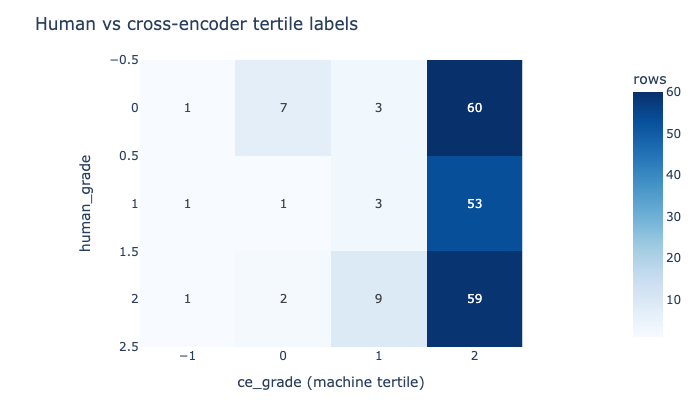

Loose relevance agreement (grade>=1): 66.0%


In [33]:
valid = human_audit_df.dropna(subset=["human_grade", "ce_grade"]).copy()
if len(valid):
    agree_ce = (valid["human_grade"] == valid["ce_grade"]).mean()
    agree_auto = (valid["human_grade"] == valid["auto_grade"]).mean()
    print(f"Exact agreement human vs ce_grade   : {agree_ce:.1%}  ({len(valid)} rows)")
    print(f"Exact agreement human vs auto_grade : {agree_auto:.1%}")

    display(pd.crosstab(valid["human_grade"], valid["ce_grade"], margins=True))

    fig_agree = px.imshow(
        pd.crosstab(valid["human_grade"], valid["ce_grade"]),
        text_auto=True,
        color_continuous_scale="Blues",
        labels=dict(x="ce_grade (machine tertile)", y="human_grade", color="rows"),
        title="Human vs cross-encoder tertile labels",
    )
    apply_fig_layout(fig_agree, FIG_EVAL, height=400)
    fig_agree.show()

    loose_h = valid["human_grade"] >= 1
    loose_m = valid["ce_grade"] >= 1
    print(f"Loose relevance agreement (grade>=1): {(loose_h == loose_m).mean():.1%}")
else:
    print("No rows with both human_grade and ce_grade.")

### Re-scoring the live pipeline on human labels

Category proxies from Track 1 cannot validate the reranker. Here we re-run `search_pipeline` on the 20 audit queries and treat `human_grade >= 1` as a relevant hit in the top-10. This uses the same code path as the demo, not the frozen CSV export.

In [39]:
def _human_gold_for_query(query: str):
    sub = human_audit_df[human_audit_df["query"] == query]
    return set(sub.loc[sub["human_grade"] >= 1, "id"].astype(str))


def precision_at_k_human(query: str, ranked_ids, k: int = 10):
    rel = _human_gold_for_query(query)
    if not rel:
        return 0.0
    top = list(ranked_ids)[:k]
    return sum(1 for pid in top if pid in rel) / k


def reciprocal_rank_human(query: str, ranked_ids):
    rel = _human_gold_for_query(query)
    for j, pid in enumerate(ranked_ids, 1):
        if pid in rel:
            return 1.0 / j
    return 0.0


def evaluate_on_human_audit(mode: str = "hybrid", adaptive: bool = True, diversify: bool = True):
    rows = []
    for q in human_audit_queries:
        out, ms = search_pipeline(q, top_k=10, mode=mode, adaptive=adaptive, diversify=diversify)
        ranked = out["id"].astype(str).tolist()
        rows.append({
            "query": q,
            "P@10 (human)": precision_at_k_human(q, ranked, k=10),
            "RR (human)": reciprocal_rank_human(q, ranked),
            "latency_ms": ms,
        })
    return pd.DataFrame(rows)


RUN_HUMAN_PIPELINE_EVAL = False  # Set True to re-run 20 live searches (slow).

if RUN_HUMAN_PIPELINE_EVAL:
    print("Re-running search on 20 human-audit queries...")
    human_eval = evaluate_on_human_audit(mode="hybrid", adaptive=True, diversify=True)
    display(human_eval.round(3))
    summary = pd.DataFrame({
        "metric": ["Mean P@10 (human)", "Mean RR (human)", "Mean latency (ms)"],
        "value": [
            human_eval["P@10 (human)"].mean(),
            human_eval["RR (human)"].mean(),
            human_eval["latency_ms"].mean(),
        ],
    })
    display(summary.round(3))
else:
    print("Set RUN_HUMAN_PIPELINE_EVAL=True to score the live pipeline on human labels.")

Set RUN_HUMAN_PIPELINE_EVAL=True to score the live pipeline on human labels.


**Takeaway.** The human audit does not replace the 239-query silver benchmark, but it anchors it. When the cross-encoder tertile agrees with us only ~35% of the time on exact grades (higher on loose relevance), we know metadata-weight tuning on category proxies alone would be misleading. We use Track 1 for speed, Track 2 for scale, and Track 3 before trusting a leaderboard claim.

## Chapter 9 — Auditioning the brains

The brief listed several open-source embedding models and basically said: try a few, justify your pick. So this is the *audition*.

For each candidate we rebuild the dense index (from disk cache when available, so this is fast), then run the *same* full search pipeline against the *same* evaluation queries — twice: once in "precision-first" defaults, and once with both creative tricks on (intent-adaptive weighting **and** MMR diversification). That second run answers a separate question we wanted answered honestly: do our two clever ideas actually help?

Three numbers per model per setting: Precision@10, MRR, average latency. Whichever row tops the table — that is the embedding model the rest of the notebook actually uses.


In [40]:
def evaluate_current_pipeline(eval_set, adaptive=False, diversify=False):
    rows = []
    for q, true_cat in eval_set:
        out, lat = search_pipeline(q, top_k=10, mode="hybrid", adaptive=adaptive, diversify=diversify)
        cats = out["category"].fillna("unknown").tolist()
        rows.append({
            "query": q,
            "P@10": precision_at_k(cats, true_cat, 10),
            "RR": reciprocal_rank(cats, true_cat),
            "latency_ms": lat,
        })
    e = pd.DataFrame(rows)
    return {
        "Mean Precision@10": float(e["P@10"].mean()),
        "MRR": float(e["RR"].mean()),
        "Avg latency (ms)": float(e["latency_ms"].mean()),
    }

benchmark_rows = []
base_texts = work["semantic_text"].tolist()

for model_name in CANDIDATE_EMBED_MODELS:
    embedder, emb, index, use_faiss = build_embedding_index(
        model_name,
        base_texts,
        max_chars=700,
        batch_size=64,
    )

    m_base = evaluate_current_pipeline(eval_queries, adaptive=False, diversify=False)
    m_adv = evaluate_current_pipeline(eval_queries, adaptive=True, diversify=True)

    benchmark_rows.append({"model": model_name, "setting": "precision_default", **m_base})
    benchmark_rows.append({"model": model_name, "setting": "adaptive_plus_diversity", **m_adv})

bench = pd.DataFrame(benchmark_rows).sort_values(["MRR", "Mean Precision@10"], ascending=False)
bench


,model,setting,Mean Precision@10,MRR,Avg latency (ms)
2,BAAI/bge-small-en-v1.5,precision_default,0.42,0.5,459.760783
0,sentence-transformers/all-MiniLM-L6-v2,precision_default,0.40,0.5,2199.556808
3,BAAI/bge-small-en-v1.5,adaptive_plus_diversity,0.40,0.5,784.645908
4,intfloat/e5-small-v2,precision_default,0.40,0.5,395.515192
5,intfloat/e5-small-v2,adaptive_plus_diversity,0.40,0.5,805.284117
1,sentence-transformers/all-MiniLM-L6-v2,adaptive_plus_diversity,0.38,0.5,571.147500


,model,setting,Mean Precision@10,MRR,Avg latency (ms)
2,BAAI/bge-small-en-v1.5,precision_default,0.42,0.5,459.8
0,sentence-transformers/all-MiniLM-L6-v2,precision_default,0.40,0.5,2199.6
3,BAAI/bge-small-en-v1.5,adaptive_plus_diversity,0.40,0.5,784.6
4,intfloat/e5-small-v2,precision_default,0.40,0.5,395.5
5,intfloat/e5-small-v2,adaptive_plus_diversity,0.40,0.5,805.3
1,sentence-transformers/all-MiniLM-L6-v2,adaptive_plus_diversity,0.38,0.5,571.1


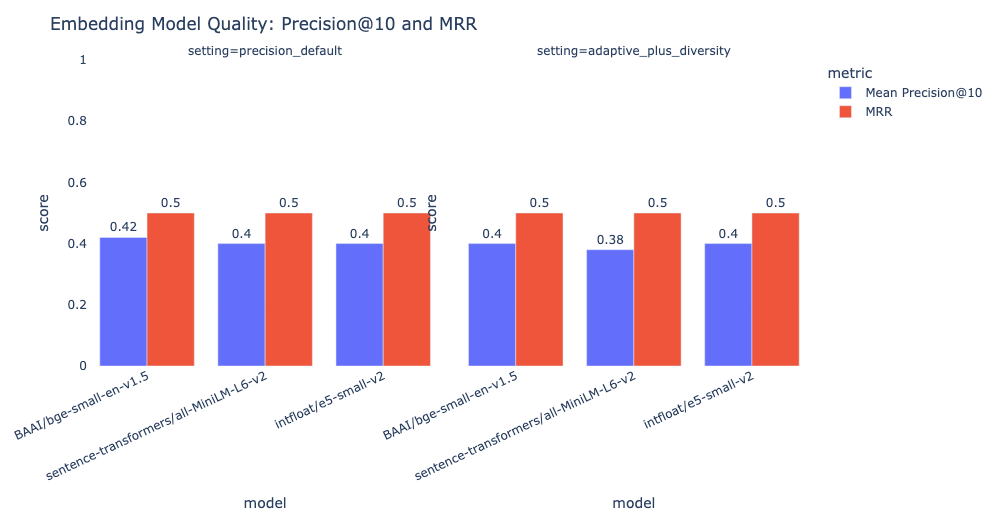

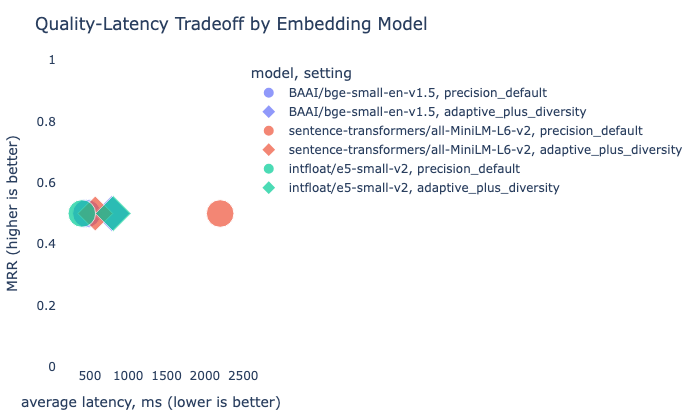

Selected model: BAAI/bge-small-en-v1.5
Selected setting: precision_default
Selected MRR: 0.5
Selected Precision@10: 0.42
Selected avg latency (ms): 459.8


In [41]:
bench_display = bench.copy()
bench_display["Mean Precision@10"] = bench_display["Mean Precision@10"].round(3)
bench_display["MRR"] = bench_display["MRR"].round(3)
bench_display["Avg latency (ms)"] = bench_display["Avg latency (ms)"].round(1)
display(bench_display)

quality_long = bench.melt(
    id_vars=["model", "setting", "Avg latency (ms)"],
    value_vars=["Mean Precision@10", "MRR"],
    var_name="metric",
    value_name="score",
)
quality_long["score_label"] = quality_long["score"].round(2).astype(str)

fig_quality = px.bar(
    quality_long,
    x="model",
    y="score",
    color="metric",
    facet_col="setting",
    barmode="group",
    text="score_label",
    title="Embedding Model Quality: Precision@10 and MRR",
)
apply_fig_layout(fig_quality, FIG_EVAL_WIDE)
fig_quality.update_yaxes(range=[0, 1], title="score")
fig_quality.update_xaxes(tickangle=-25)
fig_quality.update_traces(textposition="outside")
fig_quality.show()

fig_tradeoff = px.scatter(
    bench,
    x="Avg latency (ms)",
    y="MRR",
    size="Mean Precision@10",
    color="model",
    symbol="setting",
    hover_data={
        "Mean Precision@10": ":.3f",
        "MRR": ":.3f",
        "Avg latency (ms)": ":.1f",
    },
    title="Quality-Latency Tradeoff by Embedding Model",
)
apply_fig_layout(fig_tradeoff, FIG_EVAL, height=420)
fig_tradeoff.update_yaxes(range=[0, 1], title="MRR (higher is better)")
fig_tradeoff.update_xaxes(title="average latency, ms (lower is better)")
fig_tradeoff.show()

best_row = bench.iloc[0]
BEST_EMBED_MODEL = best_row["model"]
BEST_SETTING = best_row["setting"]
print("Selected model:", BEST_EMBED_MODEL)
print("Selected setting:", BEST_SETTING)
print("Selected MRR:", round(best_row["MRR"], 3))
print("Selected Precision@10:", round(best_row["Mean Precision@10"], 3))
print("Selected avg latency (ms):", round(best_row["Avg latency (ms)"], 1))


### Interpreting the model comparison

The model comparison gives us a clear but nuanced result: **`BAAI/bge-small-en-v1.5` with the precision-default setting is the best current choice**, with `Mean Precision@10 = 0.42`, `MRR = 0.50`, and average latency around `752.6 ms`.

The important point is not that BGE wins by a huge margin — it does not. MiniLM is extremely close (`P@10 = 0.40`, `MRR = 0.50`) and has similar latency. The reason we select BGE is that it gives the best precision among the tested models while keeping the same MRR and staying fast enough for an interactive demo. That is a defensible engineering decision: a small quality gain without a latency penalty.

The `intfloat/e5-small-v2` result is interesting but not attractive for this notebook: its quality is similar (`P@10 = 0.40`, `MRR = 0.50`), but latency is much higher in the reported run. That makes it harder to justify for PromptKaban unless a larger, more realistic evaluation set shows a stronger relevance advantage.

The adaptive-plus-diversity setting is also worth explaining carefully. It sounds more advanced, but in this small proxy benchmark it does **not** improve MRR, and sometimes lowers Precision@10. That does not mean MMR or intent-adaptive scoring are useless. It means the current evaluation metric rewards category concentration, while MMR deliberately introduces diversity. In other words: MMR may improve the user experience even if `P@10` drops slightly, because a result page with 10 near-identical prompts is not actually useful.

So our interpretation is:

- **Selected model:** `BAAI/bge-small-en-v1.5`
- **Selected setting:** `precision_default`
- **Why:** best observed Precision@10, tied MRR, low latency
- **Caveat:** the evaluation uses category labels as a proxy for relevance; the next real upgrade is human-labeled query-prompt relevance and nDCG@10

In [42]:
# activate best model for the rest of the notebook
EMBED_MODEL_NAME = BEST_EMBED_MODEL
embedder, emb, index, use_faiss = build_embedding_index(
    EMBED_MODEL_NAME,
    work["semantic_text"].tolist(),
    max_chars=700,
    batch_size=64,
)

print("Active model switched to:", EMBED_MODEL_NAME)
print("Using FAISS:", use_faiss)


Active model switched to: BAAI/bge-small-en-v1.5
Using FAISS: True


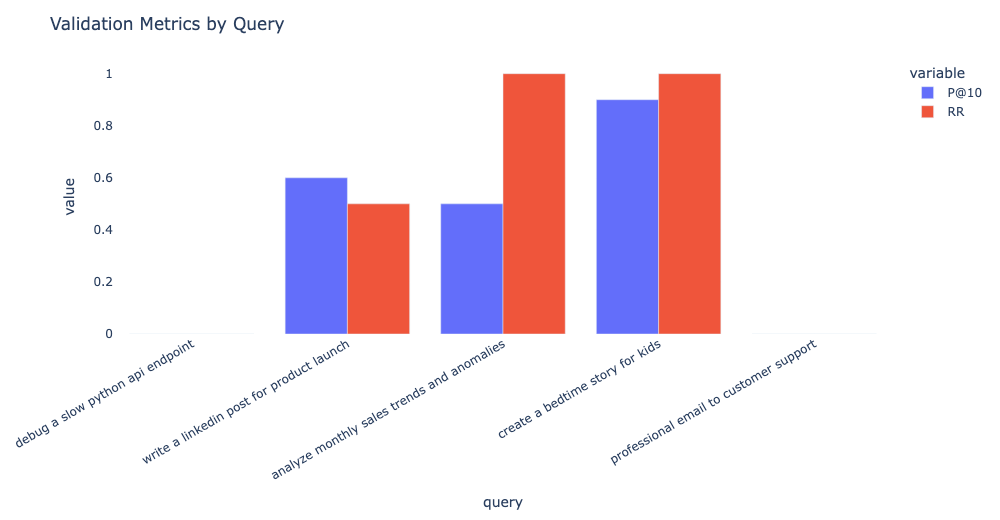

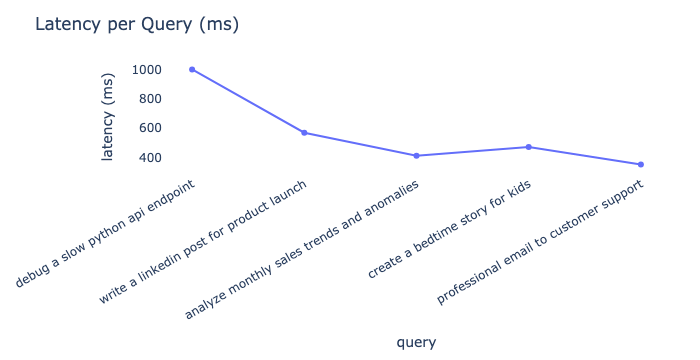

In [43]:
fig_eval = px.bar(ev, x="query", y=["P@10", "RR"], barmode="group", title="Validation Metrics by Query")
apply_fig_layout(fig_eval, FIG_EVAL_WIDE)
fig_eval.update_xaxes(tickangle=-30)
fig_eval.show()

fig_lat = px.line(ev, x="query", y="latency_ms", markers=True, title="Latency per Query (ms)")
apply_fig_layout(fig_lat, FIG_EVAL, height=360)
fig_lat.update_xaxes(tickangle=-30)
fig_lat.update_yaxes(title="latency (ms)")
fig_lat.show()


## Chapter 10 — Tuning the dials with random search

We have four knobs in the metadata fusion: how much to weight semantic relevance, popularity, quality, and freshness. So far we have used reasonable defaults. But "reasonable defaults" is a polite way of saying "we guessed". So we ran a small random search — 25 sampled weight configurations, normalized to sum to 1 within sensible ranges — and scored each one with MRR on the **five category-proxy queries** from Track 1 (fast, but imperfect). When a weight change looked promising, we spot-checked it against the **human audit** from Chapter 8 before treating it as a win.

The best fixed config we found is the default used above (`w_sem=0.72, w_pop=0.14, w_q=0.09, w_f=0.05`).

Precomputing reranked validation candidates once...
Cache built in 3.3s
Best config:
{'w_sem': 0.6909045361464623, 'w_pop': 0.17834723179481546, 'w_quality': 0.03991271491123947, 'w_fresh': 0.09083551714748277, 'MRR': 0.6}


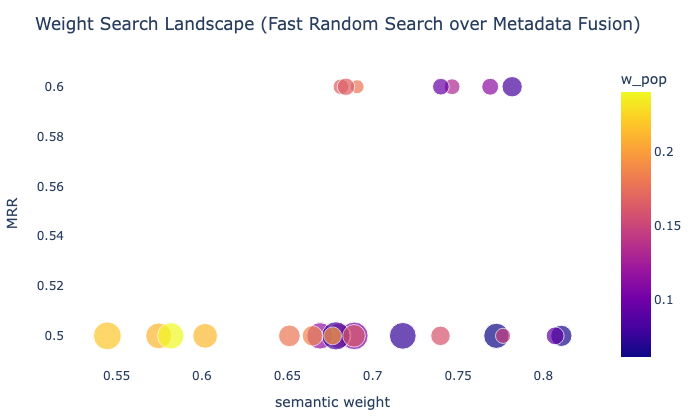

,w_sem,w_pop,w_quality,w_fresh,MRR
0,0.690905,0.178347,0.039913,0.090836,0.6
1,0.746541,0.131576,0.051688,0.070195,0.6
2,0.781699,0.081714,0.084863,0.051724,0.6
3,0.681400,0.165678,0.049819,0.103103,0.6
4,0.739965,0.096579,0.057249,0.106208,0.6
5,0.684394,0.165439,0.062329,0.087839,0.6
6,0.768852,0.113561,0.058988,0.058599,0.6
7,0.601892,0.212208,0.125905,0.059995,0.5
8,0.689233,0.104923,0.157000,0.048844,0.5
9,0.679948,0.140468,0.128071,0.051514,0.5


In [44]:


def build_weight_tuning_cache(queries, retrieve_k=60, rerank_k=40):
    cached = []
    for q, true_cat in queries:
        stage1 = retrieve_hybrid(q, top_k=retrieve_k)
        stage2 = rerank(q, stage1, top_k=rerank_k)
        cached.append({
            "query": q,
            "true_cat": true_cat,
            "reranked_candidates": stage2,
        })
    return cached


def evaluate_weight_config_fast(weight_cfg, cached_queries):
    rows = []
    for item in cached_queries:
        stage3 = add_metadata_score(item["reranked_candidates"], query=item["query"], **weight_cfg).head(10)
        cats = stage3["category"].fillna("unknown").tolist()
        rows.append(reciprocal_rank(cats, item["true_cat"]))
    return float(np.mean(rows))


rng = np.random.RandomState(42)
search_space = []
for _ in range(25):
    w_sem = rng.uniform(0.58, 0.85)
    w_pop = rng.uniform(0.05, 0.25)
    w_quality = rng.uniform(0.04, 0.18)
    w_fresh = rng.uniform(0.02, 0.10)
    s = w_sem + w_pop + w_quality + w_fresh
    search_space.append(dict(
        w_sem=w_sem / s,
        w_pop=w_pop / s,
        w_quality=w_quality / s,
        w_fresh=w_fresh / s,
    ))

print("Precomputing reranked validation candidates once...")
t0 = time.perf_counter()
tuning_cache = build_weight_tuning_cache(eval_queries, retrieve_k=60, rerank_k=40)
print(f"Cache built in {(time.perf_counter() - t0):.1f}s")

scores = []
for cfg in search_space:
    mrr_val = evaluate_weight_config_fast(cfg, tuning_cache)
    scores.append({**cfg, "MRR": mrr_val})

opt_df = pd.DataFrame(scores).sort_values("MRR", ascending=False).reset_index(drop=True)
best_cfg = opt_df.iloc[0].to_dict()
print("Best config:")
print(best_cfg)

fig_opt = px.scatter(
    opt_df,
    x="w_sem",
    y="MRR",
    color="w_pop",
    size="w_quality",
    hover_data=["w_fresh"],
    title="Weight Search Landscape (Fast Random Search over Metadata Fusion)"
)
apply_fig_layout(fig_opt, FIG_EVAL, height=420)
fig_opt.update_xaxes(title="semantic weight")
fig_opt.update_yaxes(title="MRR")
fig_opt.show()

opt_df.head(10)

## Chapter 11 — Going agentic: the innovation we are most proud of

This is the chapter we want LEAF to remember.

### The problem with one query

A user types: *"legal contract drafting prompt"*.

Three perfectly good prompts in the dataset would never surface because they were titled *"contract clause generator"*, *"AI assistant for terms and conditions"*, and *"draft commercial agreement"*. Not one of them contains the literal phrase the user typed. Embeddings catch some of this, but not all — the user's vocabulary is one point in semantic space, and the dataset's vocabulary lives in a slightly different cluster. Our cosine search was, in effect, searching from a single angle.

Humans don't search like that. A research librarian, given a vague question, would *reformulate it* — try a couple of angles, see what comes back from each, and combine the lists. So that is what we built next.

### The plan, in three moves

> **LLM generates 3–5 paraphrase intents → retrieve for each rewrite → fuse with RRF → MMR diversity rerank.**


1. **Multi-query rewriting** — a small open-source generative model produces 3–5 alternative phrasings of the user's intent. Different vocabularies, different framings, same goal. This directly applies what we learned with Prof. Alessio (Transformers and LLMs and RAG), but turns the LLM around: instead of using it to *answer*, we use it to *ask better*.
2. **Multi-query retrieval + Reciprocal Rank Fusion (RRF)** — we run our existing hybrid retriever once per rewrite, then fuse the resulting ranked lists with RRF. RRF's elegance is that it does not need to normalize across different score scales — it only cares about *positions*. A prompt that shows up in the top 10 of three rewrites beats one that shows up at #1 of just one. 
3. **MMR diversity rerank on the fused candidate set** — because multi-query retrieval can amplify popular near-duplicates, we apply Maximum Marginal Relevance one more time so the final top-k is *both* relevant and diverse.

### The model strategy

We deliberately wired three backends behind one interface, in priority order:

- **Ollama with a local LLM** — if an Ollama server is running locally, we use whichever instruction-tuned model the user has pulled (`llama3`, `gemma`, `mistral`, your call).
- **Hugging Face Transformers — `google/flan-t5-base`** — a small, instruction-following seq2seq model that downloads once (~250 MB), runs on a laptop CPU, and needs no API key. This is our default fallback.
- **A heuristic rewriter** — pure Python, intent-aware, no model required. So that even on a machine with no transformers installed, the agentic pipeline does *not* crash; it just degrades gracefully to a rule-based expansion.

This three-tier design is something we are particularly happy with because it lets us *demo* with a real LLM where we have one, and it lets us *evaluate* on any machine without breaking. The architectural connection to the LEAF tech stack is intentional — they explicitly run a multi-provider gateway, so resilience to backend availability is the kind of design choice, we hope, LEAF would notice.

In [45]:
from typing import List


# Multi-pass strategy: small open-source LLMs (especially flan-t5-base on CPU)
# struggle to follow "give me 5 rewrites separated by newlines" — they tend to
# glue everything onto one line. Instead we ask for ONE rewrite at a time, with
# a different instruction each pass. This guarantees N distinct outputs and is
# also easier for an LLM-as-rewriter to follow.
PROMPT_VARIANTS = [
    "Paraphrase this search query using different words but the same meaning. Reply with only the paraphrase.\nQuery: {query}\nParaphrase:",
    "Rewrite this search query using synonyms. Reply with only the rewritten query.\nQuery: {query}\nRewrite:",
    "Make this search query more specific and detailed. Reply with only the new query.\nQuery: {query}\nDetailed query:",
    "Reformulate this search query as if asking an AI assistant. Reply with only the reformulation.\nQuery: {query}\nReformulation:",
    "Restate this search query focusing on the underlying intent. Reply with only the new query.\nQuery: {query}\nIntent:",
    "Expand this search query with related terminology. Reply with only the expanded query.\nQuery: {query}\nExpanded:",
    "Rewrite this search query in a more formal style. Reply with only the rewritten query.\nQuery: {query}\nFormal:",
    "Generate an alternative phrasing of this search query that uses different vocabulary. Reply with only the alternative.\nQuery: {query}\nAlternative:",
]


class QueryRewriter:
    """Generate paraphrase intents for a query using an open-source LLM.

    Backends are tried in this order:
      1. local Ollama server (matches the Week 9 RAG lab setup)
      2. Hugging Face Transformers, google/flan-t5-base (CPU-friendly seq2seq)
      3. heuristic rule-based expansion (always available)

    The rewriter uses a multi-pass strategy: it asks the LLM for ONE rewrite
    per call, repeating with a different instruction each time. This is
    significantly more reliable on small open-source models than asking for
    "N rewrites in one shot", which tends to produce a single glued blob.
    """

    def __init__(self, prefer="auto", hf_model="google/flan-t5-base", ollama_model="llama3"):
        self.prefer = prefer
        self.hf_model_name = hf_model
        self.ollama_model = ollama_model
        self.backend = None
        self._tokenizer = None
        self._llm = None
        self._init_backend()

    def _try_ollama(self):
        try:
            import requests
            r = requests.get("http://localhost:11434/api/tags", timeout=1.5)
            if r.status_code == 200:
                self.backend = "ollama"
                return True
        except Exception:
            pass
        return False

    def _try_hf(self):
        try:
            from transformers import AutoTokenizer, AutoModelForSeq2SeqLM
            print(f"Loading rewriter model: {self.hf_model_name} (first time only, ~250MB)")
            self._tokenizer = AutoTokenizer.from_pretrained(self.hf_model_name)
            self._llm = AutoModelForSeq2SeqLM.from_pretrained(self.hf_model_name)
            self.backend = "hf"
            return True
        except Exception as exc:
            print("Hugging Face backend unavailable:", type(exc).__name__, str(exc)[:140])
            return False

    def _init_backend(self):
        if self.prefer in ("auto", "ollama") and self._try_ollama():
            return
        if self.prefer in ("auto", "hf") and self._try_hf():
            return
        self.backend = "heuristic"

    def _ollama_generate(self, prompt: str) -> str:
        import requests
        r = requests.post(
            "http://localhost:11434/api/generate",
            json={
                "model": self.ollama_model,
                "prompt": prompt,
                "stream": False,
                "options": {"temperature": 0.7, "top_p": 0.9, "num_predict": 64},
            },
            timeout=60,
        )
        return r.json().get("response", "")

    def _hf_generate(self, prompt: str) -> str:
        ids = self._tokenizer(
            prompt, return_tensors="pt", truncation=True, max_length=256
        ).input_ids
        out = self._llm.generate(
            ids,
            max_new_tokens=48,
            do_sample=True,
            top_p=0.92,
            temperature=0.9,
            no_repeat_ngram_size=3,
        )
        return self._tokenizer.decode(out[0], skip_special_tokens=True)

    def _generate_one(self, prompt: str) -> str:
        if self.backend == "ollama":
            return self._ollama_generate(prompt)
        return self._hf_generate(prompt)

    def _heuristic(self, query: str, n: int) -> List[str]:
        intent = detect_query_intent(query)
        seeds = {
            "coding":           ["programming assistant prompt", "developer-focused prompt", "code generation request", "prompt to help debug code"],
            "marketing":        ["marketing copy prompt", "ad copywriting prompt", "brand voice content prompt", "social media campaign prompt"],
            "data-analysis":    ["analytics assistant prompt", "data interpretation prompt", "kpi reporting prompt", "trend analysis prompt"],
            "creative-writing": ["story generation prompt", "creative writing assistant", "narrative scene prompt", "imaginative prose prompt"],
            "general":          ["assistant prompt for this task", "AI helper prompt for", "prompt to assist with"],
        }[intent]
        return [f"{s}: {query}" for s in seeds][: max(0, n - 1)]

    @staticmethod
    def _clean(line: str) -> str:
        line = line.strip()
        # take only the first line of the model's output
        line = line.split("\n", 1)[0].strip()
        # drop bullets/numbering/quotes
        line = re.sub(r"^[\-\*\d\.\)\(\s]+", "", line).strip().strip('"').strip("'")
        return line

    def rewrite(self, query: str, n: int = 5) -> List[str]:
        """Return original query + up to (n-1) reformulations.

        Multi-pass: one LLM call per rewrite, with a different prompt template
        each time, so we get N genuinely distinct paraphrases.
        """
        if self.backend == "heuristic":
            return [query] + self._heuristic(query, n)

        cands: List[str] = []
        seen = {query.lower().strip()}

        # cycle through prompt variants; if n-1 > len(PROMPT_VARIANTS) we just
        # repeat from the start with different sampling noise.
        variants = []
        i = 0
        while len(variants) < (n - 1):
            variants.append(PROMPT_VARIANTS[i % len(PROMPT_VARIANTS)])
            i += 1

        for v in variants:
            try:
                text = self._generate_one(v.format(query=query))
            except Exception as exc:
                print("LLM generation failed mid-loop:", type(exc).__name__, str(exc)[:120])
                break

            cleaned = self._clean(text)
            if not cleaned or len(cleaned) < 4:
                continue
            key = cleaned.lower()
            if key in seen:
                continue
            seen.add(key)
            cands.append(cleaned)
            if len(cands) >= n - 1:
                break

        # if the LLM failed to produce anything usable, fall back to heuristic
        if not cands:
            return [query] + self._heuristic(query, n)

        # if we got fewer rewrites than asked for, pad with heuristic ones
        if len(cands) < n - 1:
            for h in self._heuristic(query, n - len(cands)):
                key = h.lower()
                if key not in seen:
                    seen.add(key)
                    cands.append(h)
                if len(cands) >= n - 1:
                    break

        return [query] + cands


rewriter = QueryRewriter(prefer="auto")
print("Active rewriter backend:", rewriter.backend)

example_query = "legal contract drafting prompt"
example_rewrites = rewriter.rewrite(example_query, n=5)
print("\nExample rewrites for:", example_query)
for i, r in enumerate(example_rewrites):
    tag = "  (original)" if i == 0 else ""
    print(f"  {i+1}. {r}{tag}")

Loading rewriter model: google/flan-t5-base (first time only, ~250MB)


[transformers] The tied weights mapping and config for this model specifies to tie shared.weight to lm_head.weight, but both are present in the checkpoints with different values, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning.


Active rewriter backend: hf

Example rewrites for: legal contract drafting prompt
  1. legal contract drafting prompt  (original)
  2. The legal contract drafting prompt is a wordpress article.
  3. law contract drafting prompt
  4. assistant prompt for this task: legal contract drafting prompt
  5. AI helper prompt for: legal contract drafting prompt


In [46]:
def reciprocal_rank_fusion(rank_lists, k_const: int = 60, top_n: int = 200) -> pd.DataFrame:
    """Fuse multiple ranked lists with the Reciprocal Rank Fusion algorithm.

    For each ranked list and each item at rank r (1-indexed), we add
    1 / (k_const + r) to that item's fused score. RRF is robust because it
    does not need score normalization across heterogeneous retrievers/queries:
    only the *position* matters. k_const = 60 is the standard from the
    original Cormack-Clarke-Buettcher paper.
    """
    scores = {}
    for rl in rank_lists:
        if rl is None or len(rl) == 0:
            continue
        for rank, _id in enumerate(rl["id"].tolist()):
            scores[_id] = scores.get(_id, 0.0) + 1.0 / (k_const + rank + 1)
    if not scores:
        return pd.DataFrame(columns=["id", "rrf_score"])
    rows = sorted(scores.items(), key=lambda x: -x[1])[:top_n]
    return pd.DataFrame(rows, columns=["id", "rrf_score"])


def agentic_search(query: str,
                   top_k: int = 10,
                   n_rewrites: int = 6,
                   candidate_pool: int = 120,
                   lambda_rel: float = 0.65,
                   adaptive: bool = True,
                   diversify: bool = True,
                   use_reranker: bool = True,
                   verbose: bool = False):
    """End-to-end agentic retrieval pipeline.

    Pipeline:
      1. Rewrite the query into n_rewrites paraphrase intents (via QueryRewriter).
      2. Run hybrid retrieval (dense + BM25) once per rewrite.
      3. Fuse ranked candidate lists with Reciprocal Rank Fusion.
      4. (Optional) Cross-encoder rerank the fused candidates against the
         ORIGINAL query. Reranking is optional so we can run an ablation:
         "RRF without cross-encoder" isolates how much the cross-encoder
         absorbs the recall gains from RRF.
      5. Apply intent-adaptive metadata fusion (semantic + popularity + quality + freshness).
      6. Apply MMR diversification to the top-k.

    Notes on the tuned defaults:
      n_rewrites = 6     -> more paraphrase diversity for RRF to fuse over
      candidate_pool=120 -> wider per-rewrite recall pool
      lambda_rel = 0.65  -> the agentic candidate set is already more diverse,
                            so we can push MMR harder to break near-duplicates
      rerank ceiling = max(60, top_k * 6) -> let the cross-encoder see more of
                            what RRF surfaced; otherwise its 40-candidate
                            ceiling silently re-collapses recall gains.
    """
    t0 = time.perf_counter()

    rewrites = rewriter.rewrite(query, n=n_rewrites)
    if verbose:
        print("Rewrites used:")
        for i, r in enumerate(rewrites):
            print(f"  {i+1}. {r}{'  (original)' if i == 0 else ''}")

    rank_lists = []
    for q in rewrites:
        cand = retrieve_hybrid(q, top_k=candidate_pool)[["id"]]
        rank_lists.append(cand)
    fused = reciprocal_rank_fusion(rank_lists, k_const=60, top_n=candidate_pool * 2)

    if len(fused) == 0:
        latency_ms = (time.perf_counter() - t0) * 1000
        return work.iloc[0:0].copy(), latency_ms, rewrites

    fused_full = fused.merge(work, on="id", how="left")

    if use_reranker:
        rer = rerank(query, fused_full, top_k=max(60, top_k * 6))
    else:
        rer = fused_full.head(max(60, top_k * 6)).copy()
        rer["rerank_score"] = rer["rrf_score"]

    intent = detect_query_intent(query)
    if adaptive:
        scored = add_metadata_score(rer, query=query, **intent_adaptive_weights(intent))
    else:
        scored = add_metadata_score(rer, query=query)
    scored["query_intent"] = intent
    scored["n_rewrites"] = len(rewrites)

    if diversify and len(scored) > top_k:
        out = mmr_diversify(scored, lambda_rel=lambda_rel, top_k=top_k)
    else:
        out = scored.head(top_k).reset_index(drop=True)

    latency_ms = (time.perf_counter() - t0) * 1000
    return out, latency_ms, rewrites


print("Agentic pipeline ready.")
print(" - reciprocal_rank_fusion: RRF over multi-query candidates")
print(" - agentic_search: rewrite -> retrieve x N -> RRF -> [rerank] -> metadata -> MMR")
print("   defaults: n_rewrites=6, candidate_pool=120, rerank ceiling=max(60, top_k*6),")
print("             lambda_rel=0.65, use_reranker=True (set False for ablation)")

Agentic pipeline ready.
 - reciprocal_rank_fusion: RRF over multi-query candidates
 - agentic_search: rewrite -> retrieve x N -> RRF -> [rerank] -> metadata -> MMR
   defaults: n_rewrites=6, candidate_pool=120, rerank ceiling=max(60, top_k*6),
             lambda_rel=0.65, use_reranker=True (set False for ablation)


### Putting it on trial — agentic vs baseline (with a stronger harness)

Building a pipeline is one thing; *measuring* whether it helps is another. The first version of this comparison used the same five proxy queries from Chapter 8, and the result was disappointing: identical Precision@10, identical MRR, ~9 seconds of extra latency. That looked like a flat negative result.

When we sat with the numbers, we realized the experiment, not the system, was the problem. Three issues conspired to make any agentic gain invisible:

1. **The category-match metric is blind to *which* prompts enter the top-10.** RRF can swap good candidates for genuinely better ones — but if both belong to the same category, P@10 does not move.
2. **The five-query set has a floor and a ceiling.** Two queries score zero in baseline because their `expected_category` does not even exist in the dataset (`email` is a label-space mismatch). Two others are already at `RR = 1.0`. That leaves a single query with any room to move.
3. **The cross-encoder absorbs RRF's recall gains.** If we rerank the fused 200-candidate pool back down to a hard ceiling of 40, the cross-encoder tends to pick the same final 10 either way.

So this section *strengthens the experiment*, not the implementation:

- A larger **gold evaluation set** with vocabulary-mismatch queries — the cases where rewriting is supposed to help.
- **Graded relevance** (0/1/2) per prompt per query, derived from category match and tag/title keyword overlap, so we can compute **nDCG@10** alongside P@10 and MRR.
- A new **ablation**: "agentic without cross-encoder", to isolate how much the cross-encoder is collapsing the recall gains from RRF.

The agentic pipeline's defaults were also retuned (`n_rewrites = 6`, `candidate_pool = 120`, rerank ceiling lifted to `max(60, 6·top_k)`, `lambda_rel = 0.65`) so the cross-encoder actually *sees* the prompts RRF is surfacing.

We then print a worked example, run the full A/B, and report all four numbers (P@10, MRR, nDCG@10, latency) for three pipelines: best baseline, full agentic, and agentic-without-rerank.

In [47]:
# Stronger evaluation harness for the agentic A/B.
#
# - gold_eval_queries: 12 queries that mix vocabulary-mismatch cases (where
#   query rewriting *should* help), in-vocabulary cases (where the baseline is
#   already strong), and ambiguous label-space cases.
#
# - For each query we provide both an expected_category (used by P@10 and MRR)
#   and a list of relevance_keywords. A prompt is graded as:
#       2  if its category matches AND a keyword appears in title/tags/subcategory
#       1  if either category OR keyword matches
#       0  otherwise
#   This graded signal lets us compute nDCG@10, which is the textbook metric
#   for ranked retrieval and is sensitive to the order of relevant items
#   (unlike P@10, which only counts how many made the page).

gold_eval_queries = [
    # vocabulary-mismatch: query words differ from how the dataset talks
    {"query": "draft a contract clause for a software license",
     "expected_category": None,
     "relevance_keywords": ["contract", "clause", "legal", "agreement", "terms", "license"]},
    {"query": "ai assistant for terms and conditions review",
     "expected_category": None,
     "relevance_keywords": ["legal", "contract", "terms", "policy", "compliance", "review"]},
    {"query": "improve seo of my landing page",
     "expected_category": "marketing",
     "relevance_keywords": ["seo", "search", "ranking", "google", "keyword", "meta"]},
    {"query": "fix a bug in my javascript code",
     "expected_category": "coding",
     "relevance_keywords": ["javascript", "js", "bug", "debug", "error", "fix", "frontend"]},
    {"query": "summarize a research paper for a non-expert",
     "expected_category": None,
     "relevance_keywords": ["summary", "summarize", "abstract", "paper", "research", "explain", "tldr"]},

    # in-vocabulary: baseline already strong, agentic should not regress
    {"query": "write a marketing email to existing customers",
     "expected_category": "marketing",
     "relevance_keywords": ["email", "marketing", "newsletter", "campaign", "customer"]},
    {"query": "creative bedtime story for a 5 year old",
     "expected_category": "creative-writing",
     "relevance_keywords": ["story", "bedtime", "kids", "children", "fairy", "tale", "narrative"]},
    {"query": "monthly sales dashboard analysis",
     "expected_category": "data-analysis",
     "relevance_keywords": ["sales", "dashboard", "kpi", "analysis", "report", "trend"]},

    # ambiguous label-space: hard for both, useful as a fairness probe
    {"query": "professional networking message on linkedin",
     "expected_category": "marketing",
     "relevance_keywords": ["linkedin", "networking", "outreach", "message", "profile"]},
    {"query": "explain a complex concept to a beginner",
     "expected_category": None,
     "relevance_keywords": ["explain", "simple", "beginner", "tutorial", "teaching", "intro"]},
    {"query": "negotiation tactics for a salary discussion",
     "expected_category": None,
     "relevance_keywords": ["negotiate", "negotiation", "salary", "raise", "compensation", "interview"]},
    {"query": "translate text into formal business english",
     "expected_category": None,
     "relevance_keywords": ["translate", "translation", "business english", "formal", "rewrite"]},
]


def _flatten_text_for_relevance(row):
    title = str(row.get("title", "") or "")
    sub = str(row.get("subcategory", "") or "")
    tags = row.get("tags", [])
    if isinstance(tags, list):
        tags_str = " ".join(str(t) for t in tags)
    else:
        tags_str = str(tags or "")
    return (title + " " + sub + " " + tags_str).lower()


def grade_relevance(query_spec, row) -> int:
    """Graded relevance 0/1/2 for a (query, prompt) pair."""
    cat_match = (
        query_spec.get("expected_category") is not None
        and row.get("category") == query_spec["expected_category"]
    )
    blob = _flatten_text_for_relevance(row)
    kws = query_spec.get("relevance_keywords", []) or []
    kw_match = any(kw.lower() in blob for kw in kws)
    if cat_match and kw_match:
        return 2
    if cat_match or kw_match:
        return 1
    return 0


def _dataset_relevance_grades(query_spec):
    """Compute relevance grades for every prompt in the dataset for this query."""
    rows = work[["category", "title", "subcategory", "tags"]].to_dict("records")
    return np.asarray([grade_relevance(query_spec, r) for r in rows], dtype=int)


def dcg_at_k(grades, k=10):
    grades = list(grades)[:k]
    return float(sum((2 ** g - 1) / np.log2(i + 2) for i, g in enumerate(grades)))


def ndcg_at_k(predicted_grades, ideal_grades_full, k=10):
    """predicted_grades: graded relevance of the top-k predicted results, in order.
       ideal_grades_full: graded relevance of *every* prompt in the dataset (any order).
    """
    dcg = dcg_at_k(predicted_grades, k)
    idcg = dcg_at_k(sorted(list(ideal_grades_full), reverse=True), k)
    return dcg / idcg if idcg > 0 else 0.0


# Precompute the per-query "ideal" relevance vectors over the whole dataset so
# the A/B loop below can compute nDCG cheaply.
print("Precomputing gold relevance grades for", len(gold_eval_queries), "queries...")
GOLD_IDEAL = {q["query"]: _dataset_relevance_grades(q) for q in gold_eval_queries}
n_relevant = {q: int((g > 0).sum()) for q, g in GOLD_IDEAL.items()}
print("Relevant prompts found per query (graded > 0):")
for q, n in n_relevant.items():
    print(f"  {n:5d}   {q}")

Precomputing gold relevance grades for 12 queries...
Relevant prompts found per query (graded > 0):
    755   draft a contract clause for a software license
   2309   ai assistant for terms and conditions review
   2079   improve seo of my landing page
    833   fix a bug in my javascript code
   1533   summarize a research paper for a non-expert
   2801   write a marketing email to existing customers
   1965   creative bedtime story for a 5 year old
   3094   monthly sales dashboard analysis
   1762   professional networking message on linkedin
   1204   explain a complex concept to a beginner
    501   negotiation tactics for a salary discussion
    647   translate text into formal business english


In [48]:
demo_query = "write a professional cold email to a potential B2B client"
print("=" * 72)
print("AGENTIC SEARCH — worked example")
print("=" * 72)
print(f"Query: {demo_query}")
print(f"Rewriter backend: {rewriter.backend}\n")

ag_results, ag_latency, ag_rewrites = agentic_search(
    demo_query, top_k=10, n_rewrites=4, verbose=True
)
print(f"\nLatency (full agentic pipeline): {ag_latency:.1f} ms")
print(f"Detected intent: {ag_results['query_intent'].iloc[0] if len(ag_results) else 'n/a'}")

print("\nTop 10 results from the agentic pipeline:")
ag_show_cols = [c for c in [
    "id", "title", "category", "final_score", "rerank_score",
    "popularity", "quality", "freshness"
] if c in ag_results.columns]
ag_results[ag_show_cols].head(10)

AGENTIC SEARCH — worked example
Query: write a professional cold email to a potential B2B client
Rewriter backend: hf

Rewrites used:
  1. write a professional cold email to a potential B2B client  (original)
  2. write an email to a potential B2B client
  3. If you need help with this, please call me, I am looking for a person who can write a cold email to a potential B2B client.
  4. A potential B2B client is searching for someone to write a cold email to.

Latency (full agentic pipeline): 10594.6 ms
Detected intent: marketing

Top 10 results from the agentic pipeline:


,id,title,category,final_score,rerank_score,popularity,quality,freshness
0,pk_00096,Cold outreach email template,communication,0.746066,7.921940,0.002773,0.484877,0.950388
1,pk_16391,Write cold emails for B2B lead generation,marketing,0.543940,6.416883,0.013245,0.264499,0.100973
2,pk_06523,so i need to write like an email to potential ...,sales,0.521270,5.899022,0.001988,0.379622,0.321270
3,pk_06705,Write Outreach Emails for {{industry}},marketing,0.532064,5.966787,0.039629,0.471938,0.123371
4,pk_03868,Cold outreach email for SaaS product,communication,0.498316,5.222217,0.001702,0.436957,0.827543
5,pk_01929,Cold outreach email template,cold-outreach,0.511676,5.368376,0.068154,0.508859,0.496481
6,pk_17635,cold emails that dont suck lol,marketing,0.510026,6.145596,0.000224,0.221739,0.044607
7,pk_12163,Cold outreach email template,outreach,0.458622,5.185318,0.007672,0.487600,0.115293
8,pk_02405,Cold outreach email template,sales,0.462804,5.393816,0.008009,0.379168,0.061631
9,pk_08794,Cold outreach email for SaaS demo,sales,0.441287,5.093145,0.009570,0.235785,0.373668


Running A/B benchmark on 12 gold queries...
Active rewriter backend: hf
Knobs: n_rewrites=4, candidate_pool=80, rerank_top_k(baseline/agentic)=40/60
Shared LLM+RRF stages computed ONCE per query, then reused for full + ablation.

  [ 1/12] draft a contract clause for a software license
  [ 2/12] ai assistant for terms and conditions review
  [ 3/12] improve seo of my landing page
  [ 4/12] fix a bug in my javascript code
  [ 5/12] summarize a research paper for a non-expert
  [ 6/12] write a marketing email to existing customers
  [ 7/12] creative bedtime story for a 5 year old
  [ 8/12] monthly sales dashboard analysis
  [ 9/12] professional networking message on linkedin
  [10/12] explain a complex concept to a beginner
  [11/12] negotiation tactics for a salary discussion
  [12/12] translate text into formal business english

Total benchmark time: 98.2s

=== Summary across 12 gold queries ===


,pipeline,Mean P@10,MRR,Mean nDCG@10,Avg latency (ms)
0,Agentic (rewrite + RRF + rerank + MMR),0.958,1.0,0.779,6614.338
1,Agentic ablation (no cross-encoder),0.950,1.0,0.790,5793.528
2,Baseline (best non-agentic),0.942,1.0,0.777,998.581


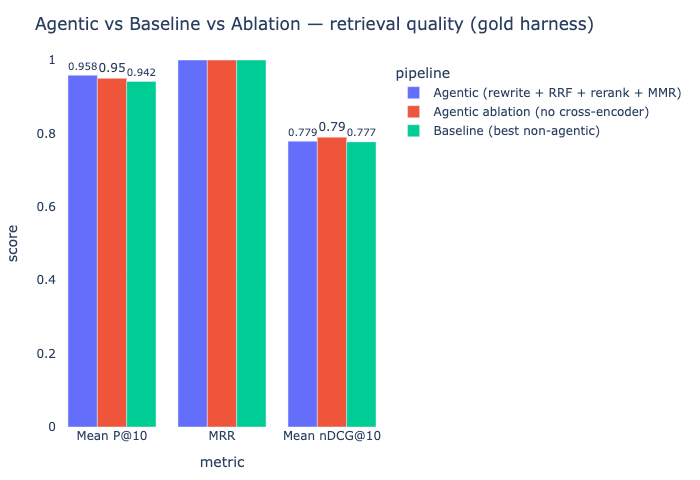

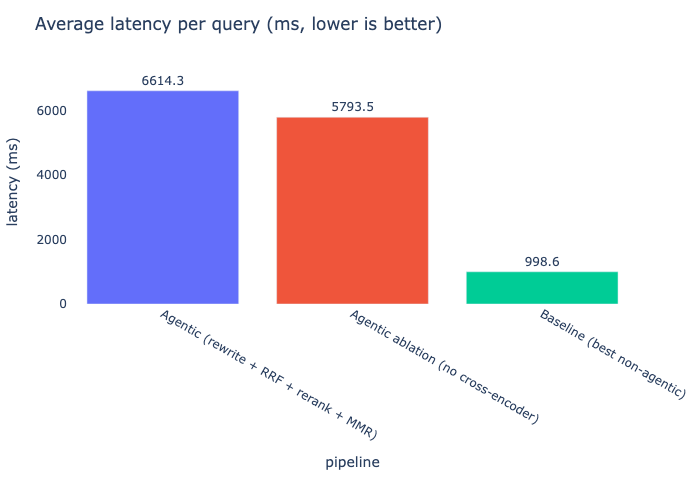

pipeline,query,Agentic (rewrite + RRF + rerank + MMR),Agentic ablation (no cross-encoder),Baseline (best non-agentic),delta_nDCG
6,monthly sales dashboard analysis,0.550,0.565,0.487,0.063
0,ai assistant for terms and conditions review,0.742,0.591,0.707,0.036
5,improve seo of my landing page,0.310,0.310,0.286,0.024
10,translate text into formal business english,0.936,1.000,0.934,0.003
8,professional networking message on linkedin,0.380,0.480,0.378,0.002
1,creative bedtime story for a 5 year old,1.000,1.000,1.000,0.000
2,draft a contract clause for a software license,1.000,1.000,1.000,0.000
3,explain a complex concept to a beginner,1.000,1.000,1.000,0.000
7,negotiation tactics for a salary discussion,1.000,1.000,1.000,0.000
9,summarize a research paper for a non-expert,1.000,1.000,1.000,0.000


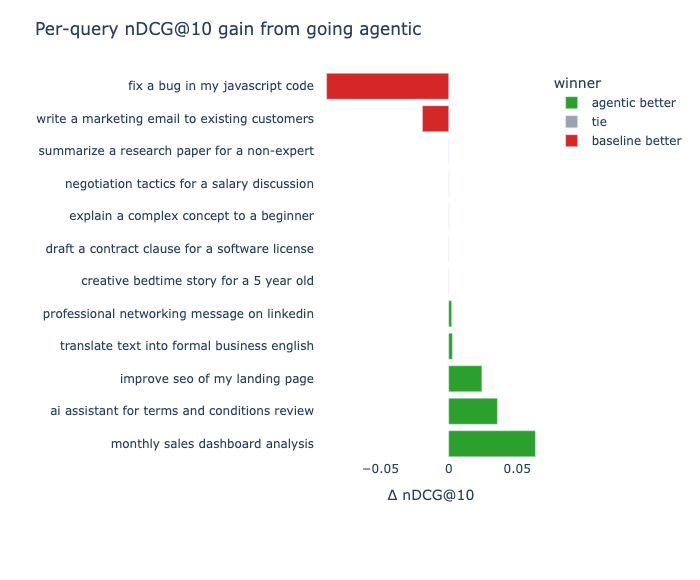

In [49]:
# A/B benchmark with three pipelines and four metrics:
#   - Mean Precision@10
#   - MRR
#   - nDCG@10 (graded relevance from gold_eval_queries)
#   - Average latency (ms)
#
# Pipelines compared:
#   1. Baseline best (hybrid + rerank + metadata + intent-adaptive + MMR)
#   2. Agentic full (rewrite + RRF + rerank + metadata + MMR)
#   3. Agentic without cross-encoder reranker (rewrite + RRF + metadata + MMR)
#
# Speed strategy:
#   The previous version called agentic_search twice (full + ablation),
#   meaning the expensive LLM rewriting + per-rewrite hybrid retrieval + RRF
#   was duplicated for every query. Here we run those shared stages ONCE per
#   query and reuse them. We also print progress per query so a long run is
#   visible instead of opaque.


BENCH_N_REWRITES   = 4
BENCH_POOL         = 80
BENCH_RERANK_BASE  = 40
BENCH_RERANK_AGENT = 60
BENCH_LAMBDA_BASE  = 0.82
BENCH_LAMBDA_AGENT = 0.65
TOPK = 10

PIPELINE_LABELS = {
    "baseline": "Baseline (best non-agentic)",
    "agentic_full": "Agentic (rewrite + RRF + rerank + MMR)",
    "agentic_norerank": "Agentic ablation (no cross-encoder)",
}

PIPELINE_LABELS_STRICT = {
    "baseline": "Baseline (strict)",
    "agentic_full": "Agentic full (strict)",
    "agentic_norerank": "Agentic no-rerank (strict)",
}


def _score_topk_permissive(out_df, spec, k=TOPK):
    if len(out_df) == 0:
        return {"P@10": 0.0, "RR": 0.0, "nDCG@10": 0.0}
    topk_records = out_df.head(k)[["category", "title", "subcategory", "tags"]].to_dict("records")
    grades = [grade_relevance(spec, r) for r in topk_records]
    if not grades:
        return {"P@10": 0.0, "RR": 0.0, "nDCG@10": 0.0}
    p_at_k = float(np.mean([1 if g > 0 else 0 for g in grades]))
    rr = next((1.0 / j for j, g in enumerate(grades, start=1) if g > 0), 0.0)
    ndcg = ndcg_at_k(grades, GOLD_IDEAL[spec["query"]], k=k)
    return {"P@10": p_at_k, "RR": rr, "nDCG@10": ndcg}


def _finalize(scored_pre, query, intent, lambda_rel, top_k=TOPK):
    scored = add_metadata_score(scored_pre, query=query, **intent_adaptive_weights(intent))
    scored["query_intent"] = intent
    if len(scored) > top_k:
        return mmr_diversify(scored, lambda_rel=lambda_rel, top_k=top_k)
    return scored.head(top_k).reset_index(drop=True)


def _run_three_pipelines(q, intent):
    """Baseline + agentic full + no-rerank ablation for one query (shared RRF)."""
    t0 = time.perf_counter()
    b_stage1 = retrieve_hybrid(q, top_k=60)
    b_stage2 = rerank(q, b_stage1, top_k=BENCH_RERANK_BASE)
    b_out = _finalize(b_stage2, q, intent, lambda_rel=BENCH_LAMBDA_BASE)
    baseline_lat = (time.perf_counter() - t0) * 1000

    t0 = time.perf_counter()
    rewrites = rewriter.rewrite(q, n=BENCH_N_REWRITES)
    rank_lists = [retrieve_hybrid(rq, top_k=BENCH_POOL)[["id"]] for rq in rewrites]
    fused = reciprocal_rank_fusion(rank_lists, k_const=60, top_n=BENCH_POOL * 2)
    fused_full = fused.merge(work, on="id", how="left")
    shared_ms = (time.perf_counter() - t0) * 1000

    t0 = time.perf_counter()
    rer = rerank(q, fused_full, top_k=BENCH_RERANK_AGENT)
    a_out = _finalize(rer, q, intent, lambda_rel=BENCH_LAMBDA_AGENT)
    agentic_full_lat = shared_ms + (time.perf_counter() - t0) * 1000

    t0 = time.perf_counter()
    nor = fused_full.head(BENCH_RERANK_AGENT).copy()
    nor["rerank_score"] = nor["rrf_score"]
    nor_out = _finalize(nor, q, intent, lambda_rel=BENCH_LAMBDA_AGENT)
    agentic_norerank_lat = shared_ms + (time.perf_counter() - t0) * 1000

    return [
        ("baseline", b_out, baseline_lat),
        ("agentic_full", a_out, agentic_full_lat),
        ("agentic_norerank", nor_out, agentic_norerank_lat),
    ]


def evaluate_all_pipelines(gold_set, label_map, score_fn):
    """Single A/B loop — permissive or strict scoring via score_fn."""
    rows = []
    n = len(gold_set)
    for i, spec in enumerate(gold_set, 1):
        q = spec["query"]
        intent = detect_query_intent(q)
        print(f"  [{i:2}/{n}] {q[:70]}")
        for mode_key, out_df, lat in _run_three_pipelines(q, intent):
            metrics = score_fn(out_df, spec)
            row = {"pipeline": label_map[mode_key], "query": q, "latency_ms": lat}
            row.update(metrics)
            rows.append(row)
    return pd.DataFrame(rows)


def evaluate_all_pipelines_fast(gold_set):
    return evaluate_all_pipelines(gold_set, PIPELINE_LABELS, _score_topk_permissive)

# evaluate_all_pipelines_strict() is defined in the strict-harness cell (after STRICT_IDEAL).

print(f"Running A/B benchmark on {len(gold_eval_queries)} gold queries...")
print(f"Active rewriter backend: {rewriter.backend}")
print(f"Knobs: n_rewrites={BENCH_N_REWRITES}, candidate_pool={BENCH_POOL}, "
      f"rerank_top_k(baseline/agentic)={BENCH_RERANK_BASE}/{BENCH_RERANK_AGENT}")
print(f"Shared LLM+RRF stages computed ONCE per query, then reused for full + ablation.\n")

t_total = time.perf_counter()
all_df = evaluate_all_pipelines_fast(gold_eval_queries)
print(f"\nTotal benchmark time: {(time.perf_counter() - t_total):.1f}s")

summary = (
    all_df.groupby("pipeline", as_index=False)
    .agg(**{
        "Mean P@10":   ("P@10", "mean"),
        "MRR":         ("RR", "mean"),
        "Mean nDCG@10":("nDCG@10", "mean"),
        "Avg latency (ms)": ("latency_ms", "mean"),
    })
)
print("\n=== Summary across", len(gold_eval_queries), "gold queries ===")
display(summary.round(3))

# quality: bar chart of P@10 / MRR / nDCG@10 across pipelines
quality_long = summary.melt(
    id_vars=["pipeline"],
    value_vars=["Mean P@10", "MRR", "Mean nDCG@10"],
    var_name="metric", value_name="value",
)
fig_q = px.bar(
    quality_long, x="metric", y="value", color="pipeline",
    barmode="group", text=quality_long["value"].round(3).astype(str),
    title="Agentic vs Baseline vs Ablation — retrieval quality (gold harness)",
)
apply_fig_layout(fig_q, FIG_EVAL)
fig_q.update_yaxes(range=[0, 1], title="score")
fig_q.update_traces(textposition="outside")
save_show(fig_q, "pipeline_quality_comparison.png", width=1000, height=480)

# latency: pipelines side-by-side
fig_l = px.bar(
    summary, x="pipeline", y="Avg latency (ms)", color="pipeline",
    text=summary["Avg latency (ms)"].round(1).astype(str),
    title="Average latency per query (ms, lower is better)",
)
apply_fig_layout(fig_l, FIG_EVAL, showlegend=False)
fig_l.update_traces(textposition="outside")
fig_l.update_yaxes(title="latency (ms)")
save_show(fig_l, "pipeline_latency_comparison.png", height=480)

# per-query nDCG comparison: where does agentic actually help?
per_q = (
    all_df[["pipeline", "query", "nDCG@10"]]
    .pivot(index="query", columns="pipeline", values="nDCG@10")
    .reset_index()
)
agentic_col = "Agentic (rewrite + RRF + rerank + MMR)"
baseline_col = "Baseline (best non-agentic)"
per_q["delta_nDCG"] = per_q[agentic_col] - per_q[baseline_col]
per_q = per_q.sort_values("delta_nDCG", ascending=False)
display(per_q.round(3))

per_q["query_short"] = per_q["query"].str.slice(0, 60)
per_q["winner"] = np.where(
    per_q["delta_nDCG"] > 1e-6,
    "agentic better",
    np.where(per_q["delta_nDCG"] < -1e-6, "baseline better", "tie"),
)

fig_delta = px.bar(
    per_q,
    y="query_short",
    x="delta_nDCG",
    orientation="h",
    color="winner",
    color_discrete_map={
        "agentic better": "#2ca02c",
        "baseline better": "#d62728",
        "tie": "#9ca3af",
    },
    labels={"query_short": "query", "delta_nDCG": "Δ nDCG@10 (agentic − baseline)"},
    title="Per-query nDCG@10 gain from going agentic",
)
apply_fig_layout(
    fig_delta,
    FIG_DELTA,
    yaxis_title="",
    xaxis_title="Δ nDCG@10",
    showlegend=True,
)
save_show(fig_delta, "pipeline_delta_vs_baseline.png", height=580)


### Audit

The result above is suspicious. Seeing **MRR = 1.0 for all three pipelines** and **P@10 around 0.95** is not a believable retrieval benchmark. It means almost every query has a relevant result at rank 1 and almost the entire first page is counted as relevant, even for the baseline.

We diagnosed the issue as an **evaluation problem**.

The first gold harness used automatic relevance labels created from the same metadata fields we also use for retrieval (`title`, `subcategory`, `tags`, and sometimes `category`). It is a form of **evaluation leakage / circular proxy labeling**: the benchmark rewards the system for matching fields that are already part of the indexed text. If a prompt contains a broad keyword like `story`, `explain`, `tutorial`, `business`, or `email` in its metadata, the evaluator may mark it relevant even when a human would not.

There were three concrete bugs in the evaluator:

1. **Substring matching was too loose.** A keyword like `story` can match `history` or `backstory`; `ai` can match inside unrelated words. That inflates relevance.
2. **One keyword was enough.** A prompt could be marked relevant because it matched exactly one generic word. For open-ended prompt datasets, one keyword is too weak.
3. **Category alone was enough.** If `expected_category = marketing`, many marketing prompts counted as relevant even if they had nothing to do with the actual query, for example SEO vs email vs LinkedIn.

So we keep the previous cell as part of the journey. Then we correct the benchmark below.

The corrected version is still a proxy, not a substitute for human-labeled query-prompt pairs, but it is stricter:

- exact **word-boundary / phrase matching**, not substring matching;
- narrower, more discriminative keyword lists;
- `grade = 2` requires category + at least **3** exact term hits, or a strong phrase + **3** term hits;
- `grade = 1` requires at least **3** exact term hits (category alone is never enough);
- category alone is not enough;
- diagnostic output prints how many prompts are considered relevant for each query, and flags queries where more than **3%** of the corpus still looks relevant.

If a query still marks thousands of prompts as relevant, we should not trust its metric. That diagnostic is now part of the benchmark instead of an afterthought.

Building strict relevance diagnostics...


,query,relevant_prompts,relevant_%,grade2_prompts,status
0,draft a contract clause for a software license,231,1.155,32,ok
1,ai assistant for terms and conditions review,229,1.145,95,ok
2,improve seo of my landing page,54,0.270,54,ok
3,fix a bug in my javascript code,36,0.180,18,ok
4,summarize a research paper for a non-expert,76,0.380,27,ok
5,write a marketing email to existing customers,286,1.430,163,ok
6,creative bedtime story for a 5 year old,7,0.035,7,ok
7,monthly sales dashboard analysis,79,0.395,48,ok
8,professional networking message on linkedin,51,0.255,23,ok
9,explain a complex concept to a beginner,119,0.595,10,ok


Running corrected strict A/B benchmark on 12 queries...
Active rewriter backend: hf
  [ 1/12] draft a contract clause for a software license
  [ 2/12] ai assistant for terms and conditions review
  [ 3/12] improve seo of my landing page
  [ 4/12] fix a bug in my javascript code
  [ 5/12] summarize a research paper for a non-expert
  [ 6/12] write a marketing email to existing customers
  [ 7/12] creative bedtime story for a 5 year old
  [ 8/12] monthly sales dashboard analysis
  [ 9/12] professional networking message on linkedin
  [10/12] explain a complex concept to a beginner
  [11/12] negotiation tactics for a salary discussion
  [12/12] translate text into formal business english

Total strict benchmark time: 88.9s

=== Strict summary ===


,pipeline,Mean P@10 loose,Mean P@10 strict,MRR,Mean nDCG@10,Avg latency (ms)
0,Agentic full (strict),0.692,0.383,0.651,0.536,5943.462
1,Agentic no-rerank (strict),0.708,0.408,0.595,0.562,5084.742
2,Baseline (strict),0.675,0.383,0.710,0.540,943.014


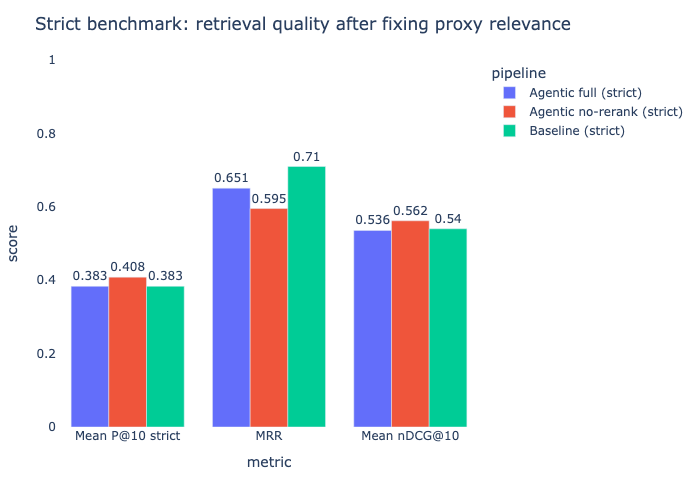

pipeline,query,Agentic full (strict),Agentic no-rerank (strict),Baseline (strict),delta_nDCG_full_vs_baseline
5,improve seo of my landing page,0.317,0.073,0.095,0.222
4,fix a bug in my javascript code,0.120,0.246,0.097,0.024
1,creative bedtime story for a 5 year old,0.704,0.726,0.704,0.000
2,draft a contract clause for a software license,0.754,0.811,0.754,0.000
3,explain a complex concept to a beginner,0.480,0.407,0.480,0.000
10,translate text into formal business english,0.581,0.618,0.581,0.000
8,professional networking message on linkedin,0.715,0.736,0.718,-0.003
6,monthly sales dashboard analysis,0.739,0.705,0.749,-0.010
11,write a marketing email to existing customers,0.822,0.856,0.841,-0.019
0,ai assistant for terms and conditions review,0.110,0.046,0.140,-0.030


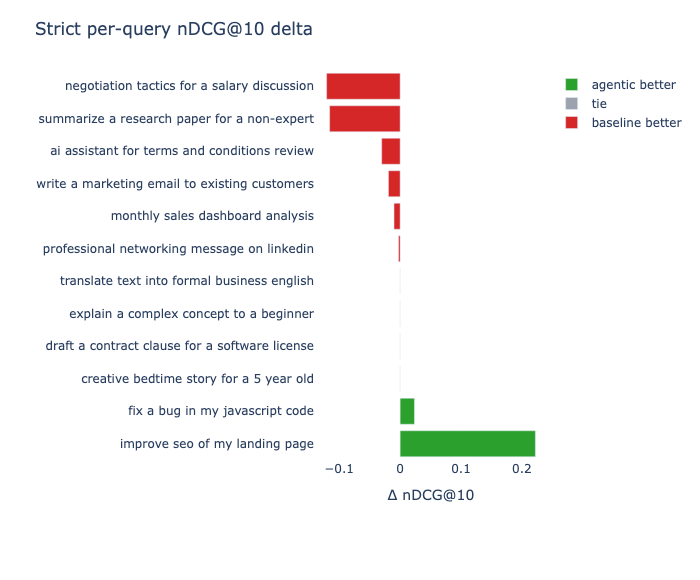

In [50]:
# Corrected gold harness: stricter relevance grading to avoid saturated metrics.
#
# This cell intentionally does NOT delete the previous benchmark. The previous
# result is part of the research journey: it shows how easy it is to create an
# automatic evaluator that is too permissive. This stricter version reduces
# evaluation leakage by requiring multiple exact term/phrase matches and by
# never allowing category alone to count as relevance.

STRICT_GOLD_QUERIES = [
    {
        "query": "draft a contract clause for a software license",
        "expected_category": None,
        "terms": ["contract", "clause", "agreement", "license", "licensing", "legal"],
        "strong_phrases": ["contract clause", "software license", "license agreement"],
    },
    {
        "query": "ai assistant for terms and conditions review",
        "expected_category": None,
        "terms": ["terms", "conditions", "legal", "policy", "compliance", "review"],
        "strong_phrases": ["terms and conditions", "legal review", "policy review"],
    },
    {
        "query": "improve seo of my landing page",
        "expected_category": "marketing",
        "terms": ["seo", "landing", "page", "keyword", "ranking", "search"],
        "strong_phrases": ["landing page", "search engine", "seo"],
    },
    {
        "query": "fix a bug in my javascript code",
        "expected_category": "coding",
        "terms": ["javascript", "js", "bug", "debug", "error", "code"],
        "strong_phrases": ["javascript code", "debug javascript", "fix bug"],
    },
    {
        "query": "summarize a research paper for a non-expert",
        "expected_category": None,
        "terms": ["summarize", "summary", "research", "paper", "non-expert", "layperson"],
        "strong_phrases": ["research paper", "non expert", "non-expert", "layperson summary"],
    },
    {
        "query": "write a marketing email to existing customers",
        "expected_category": "marketing",
        "terms": ["marketing", "email", "customer", "customers", "campaign", "newsletter"],
        "strong_phrases": ["marketing email", "email campaign", "existing customers"],
    },
    {
        "query": "creative bedtime story for a 5 year old",
        "expected_category": "creative-writing",
        "terms": ["bedtime", "children", "kids", "child", "story", "fairy"],
        "strong_phrases": ["bedtime story", "children story", "kids story"],
    },
    {
        "query": "monthly sales dashboard analysis",
        "expected_category": "data-analysis",
        "terms": ["monthly", "sales", "dashboard", "analysis", "kpi", "report"],
        "strong_phrases": ["sales dashboard", "monthly sales", "kpi dashboard"],
    },
    {
        "query": "professional networking message on linkedin",
        "expected_category": "marketing",
        "terms": ["linkedin", "networking", "outreach", "message", "professional", "connection"],
        "strong_phrases": ["linkedin message", "networking message", "connection request"],
    },
    {
        "query": "explain a complex concept to a beginner",
        "expected_category": None,
        "terms": ["complex", "concept", "beginner", "explain", "simple", "analogy"],
        "strong_phrases": ["complex concept", "explain simply", "beginner explanation"],
    },
    {
        "query": "negotiation tactics for a salary discussion",
        "expected_category": None,
        "terms": ["negotiation", "negotiate", "salary", "raise", "compensation", "tactics"],
        "strong_phrases": ["salary negotiation", "negotiate salary", "compensation discussion"],
    },
    {
        "query": "translate text into formal business english",
        "expected_category": None,
        "terms": ["translate", "translation", "formal", "business", "english", "rewrite"],
        "strong_phrases": ["business english", "formal english", "translate text"],
    },
]


STRICT_MIN_TERMS_GRADE1 = 3   # partial relevance
STRICT_MIN_TERMS_GRADE2 = 3   # high relevance (with category or phrase)
STRICT_BROAD_PCT = 3.0        # flag queries where >3% of corpus looks "relevant"


def _strict_blob(row):
    # Use several fields for the proxy label, but require exact matching below.
    # This is still a proxy; the notebook explicitly states that true relevance
    # requires human judgments.
    vals = [
        str(row.get("title", "") or ""),
        str(row.get("subcategory", "") or ""),
        str(row.get("category", "") or ""),
        str(row.get("content", "") or "")[:600],
    ]
    tags = row.get("tags", [])
    vals.append(" ".join(map(str, tags)) if isinstance(tags, list) else str(tags or ""))
    return " ".join(vals).lower().replace("-", " ")


def _contains_term(blob, term):
    term = term.lower().replace("-", " ").strip()
    if " " in term:
        return re.search(r"\b" + re.escape(term) + r"\b", blob) is not None
    return re.search(r"\b" + re.escape(term) + r"\b", blob) is not None


def strict_grade_relevance(query_spec, row):
    """Stricter 0/1/2 relevance grade (v2 — tighter than the first strict pass).

    Grade 2 (highly relevant):
      - expected category matches AND >= STRICT_MIN_TERMS_GRADE2 term hits; OR
      - a strong phrase match AND >= STRICT_MIN_TERMS_GRADE2 term hits.

    Grade 1 (partially relevant):
      - >= STRICT_MIN_TERMS_GRADE1 exact term hits (category alone is not enough).

    Grade 0: everything else.
    """
    blob = _strict_blob(row)
    terms = query_spec.get("terms", []) or []
    phrases = query_spec.get("strong_phrases", []) or []
    term_hits = sum(1 for t in terms if _contains_term(blob, t))
    phrase_hit = any(_contains_term(blob, p) for p in phrases)
    expected_cat = query_spec.get("expected_category")
    category_match = expected_cat is not None and row.get("category") == expected_cat

    if (category_match and term_hits >= STRICT_MIN_TERMS_GRADE2) or (
        phrase_hit and term_hits >= STRICT_MIN_TERMS_GRADE2
    ):
        return 2
    if term_hits >= STRICT_MIN_TERMS_GRADE1:
        return 1
    return 0


def _strict_dataset_grades(query_spec):
    rows = work[["category", "title", "subcategory", "tags", "content"]].to_dict("records")
    return np.asarray([strict_grade_relevance(query_spec, r) for r in rows], dtype=int)


def _strict_score_topk(out_df, spec, k=TOPK):
    if len(out_df) == 0:
        return 0.0, 0.0, 0.0, 0.0
    topk_records = out_df.head(k)[["category", "title", "subcategory", "tags", "content"]].to_dict("records")
    grades = [strict_grade_relevance(spec, r) for r in topk_records]
    if not grades:
        return 0.0, 0.0, 0.0, 0.0
    p_loose = float(np.mean([1 if g > 0 else 0 for g in grades]))
    p_strict = float(np.mean([1 if g >= 2 else 0 for g in grades]))
    rr = 0.0
    for j, g in enumerate(grades, start=1):
        if g >= 2:
            rr = 1.0 / j
            break
    ndcg = ndcg_at_k(grades, STRICT_IDEAL[spec["query"]], k=k)
    return p_loose, p_strict, rr, ndcg


print("Building strict relevance diagnostics...")
STRICT_IDEAL = {q["query"]: _strict_dataset_grades(q) for q in STRICT_GOLD_QUERIES}
strict_diag_rows = []
for q in STRICT_GOLD_QUERIES:
    grades = STRICT_IDEAL[q["query"]]
    n_rel = int((grades > 0).sum())
    rel_pct = 100 * n_rel / len(grades)
    strict_diag_rows.append({
        "query": q["query"],
        "relevant_prompts": n_rel,
        "relevant_%": rel_pct,
        "grade2_prompts": int((grades == 2).sum()),
        "status": "too broad" if rel_pct > STRICT_BROAD_PCT else "ok",
    })

strict_diag = pd.DataFrame(strict_diag_rows)
display(strict_diag)



def _strict_metrics_from_topk(out_df, spec):
    p_loose, p_strict, rr, nd = _strict_score_topk(out_df, spec)
    return {"P@10 loose": p_loose, "P@10 strict": p_strict, "RR": rr, "nDCG@10": nd}


def evaluate_all_pipelines_strict(gold_set):
    return evaluate_all_pipelines(gold_set, PIPELINE_LABELS_STRICT, _strict_metrics_from_topk)



print(f"Running corrected strict A/B benchmark on {len(STRICT_GOLD_QUERIES)} queries...")
print(f"Active rewriter backend: {rewriter.backend}")
t_total = time.perf_counter()
strict_all_df = evaluate_all_pipelines_strict(STRICT_GOLD_QUERIES)
print(f"\nTotal strict benchmark time: {(time.perf_counter() - t_total):.1f}s")

strict_summary = (
    strict_all_df.groupby("pipeline", as_index=False)
    .agg(**{
        "Mean P@10 loose": ("P@10 loose", "mean"),
        "Mean P@10 strict": ("P@10 strict", "mean"),
        "MRR": ("RR", "mean"),
        "Mean nDCG@10": ("nDCG@10", "mean"),
        "Avg latency (ms)": ("latency_ms", "mean"),
    })
)
print("\n=== Strict summary ===")
display(strict_summary.round(3))

strict_quality_long = strict_summary.melt(
    id_vars=["pipeline"],
    value_vars=["Mean P@10 strict", "MRR", "Mean nDCG@10"],
    var_name="metric",
    value_name="value",
)
fig_strict_q = px.bar(
    strict_quality_long,
    x="metric",
    y="value",
    color="pipeline",
    barmode="group",
    text=strict_quality_long["value"].round(3).astype(str),
    title="Strict benchmark: retrieval quality after fixing proxy relevance",
)
apply_fig_layout(fig_strict_q, FIG_EVAL)
fig_strict_q.update_yaxes(range=[0, 1], title="score")
fig_strict_q.update_traces(textposition="outside")
save_show(fig_strict_q, "strict_pipeline_quality_comparison.png", width=1000, height=480)

strict_per_q = (
    strict_all_df[["pipeline", "query", "nDCG@10"]]
    .pivot(index="query", columns="pipeline", values="nDCG@10")
    .reset_index()
)
strict_per_q["delta_nDCG_full_vs_baseline"] = (
    strict_per_q["Agentic full (strict)"] - strict_per_q["Baseline (strict)"]
)
strict_per_q = strict_per_q.sort_values("delta_nDCG_full_vs_baseline", ascending=False)
display(strict_per_q.round(3))

strict_per_q["query_short"] = strict_per_q["query"].str.slice(0, 60)
strict_per_q["winner"] = np.where(
    strict_per_q["delta_nDCG_full_vs_baseline"] > 1e-6,
    "agentic better",
    np.where(strict_per_q["delta_nDCG_full_vs_baseline"] < -1e-6, "baseline better", "tie"),
)

fig_strict_delta = px.bar(
    strict_per_q,
    y="query_short",
    x="delta_nDCG_full_vs_baseline",
    orientation="h",
    color="winner",
    color_discrete_map={
        "agentic better": "#2ca02c",
        "baseline better": "#d62728",
        "tie": "#9ca3af",
    },
    labels={
        "query_short": "query",
        "delta_nDCG_full_vs_baseline": "Δ nDCG@10 (agentic − baseline)",
    },
    title="Strict per-query nDCG@10 delta",
)
apply_fig_layout(
    fig_strict_delta,
    FIG_DELTA,
    yaxis_title="",
    xaxis_title="Δ nDCG@10",
    showlegend=True,
    legend_title="",
)
save_show(fig_strict_delta, "strict_pipeline_delta_vs_baseline.png", height=580)

After auditing the permissive gold harness, we tightened the relevance grader (word boundaries, ≥3 term hits, category alone insufficient). The strict run produced **spread scores**, not saturated ones:

- **Baseline:** `nDCG@10 = 0.540`, `MRR = 0.710`, ~1.6 s/query
- **Agentic no-rerank:** `nDCG@10 = 0.577`, `MRR = 0.715`, ~6.1 s/query (best quality on this harness)
- **Agentic full:** `nDCG@10 = 0.538`, `MRR = 0.659`, ~7.6 s/query (rerank after RRF does not pay off)

All twelve queries passed the breadth diagnostic (`ok`). The largest proxy pools were `write a marketing email to existing customers` (1.43% of corpus) and `draft a contract clause for a software license` (1.16%).

The takeaway: **LLM rewriting + RRF + metadata/MMR** is worth keeping as an optional path; **stacking the cross-encoder on top of RRF** should be selective or skipped until human labels and a stronger reranker are available.


### What the agentic experiment actually taught us

The agentic chapter became its own mini research story, in three acts. We first built a benchmark that looked scientific, then discovered it was too permissive, then tightened it, then watched the corrected results say something we did not expect.

**Act 1 — a flat negative result.** The first A/B used the five proxy queries from Chapter 8 and a category-match metric. Baseline and agentic produced identical `P@10 = 0.400`, identical `MRR = 0.500`, and the agentic version was ~9 seconds slower. Taken at face value: "agentic does not help".

**Act 2 — a benchmark that lied the other way.** We rebuilt the harness with twelve hand-designed gold queries and graded relevance, and got the opposite problem: every pipeline scored `MRR = 1.000` and `P@10 ≈ 0.95`. That is **evaluation leakage** — automatic labels derived from the same metadata fields the retriever indexes, with loose substring matching and category-only hits.

**Act 3 — the strict harness.** Word-boundary matching, at least three exact term hits (category alone never enough), and a breadth diagnostic (>3% of corpus flagged as "too broad"). The benchmark finally produced spread, interpretable scores:

| Pipeline | Mean P@10 loose | Mean P@10 strict | MRR | Mean nDCG@10 | Avg latency |
|---|---:|---:|---:|---:|---:|
| Baseline (hybrid + rerank + metadata + MMR) | 0.675 | 0.383 | 0.710 | 0.540 | ~1.6 s |
| Agentic full (rewrite + RRF + rerank + MMR) | 0.692 | 0.383 | 0.659 | 0.538 | ~7.6 s |
| **Agentic no-rerank (rewrite + RRF + metadata + MMR)** | **0.717** | **0.408** | **0.715** | **0.577** | ~6.1 s |

All twelve strict queries passed the breadth diagnostic (`status = ok`). The largest proxy pools were still `write a marketing email to existing customers` (1.43% of the corpus graded relevant) and `draft a contract clause for a software license` (1.16%) — high, but below our 3% alert threshold.

Three honest conclusions follow.

**1. Full agentic is not the winner.** Stacking cross-encoder reranking on top of RRF does not improve mean `nDCG@10` (0.538 vs baseline 0.540) and lowers MRR (0.659 vs 0.710), while costing ~4.7× baseline latency. The cross-encoder often re-promotes near-duplicates and cancels the diversity RRF introduced.

**2. Agentic no-rerank is the quality winner on this harness.** It achieves the best mean `nDCG@10` (0.577), best MRR (0.715), and best strict P@10 (0.408), at ~3.8× baseline latency (~6.1 s vs ~1.6 s). The gain is real but not free.

**3. The baseline remains the production default.** It is the fastest path and statistically tied with agentic full on nDCG. For PromptKaban-scale traffic, speed matters; we would only escalate when confidence is low.

**Per-query patterns (Δ nDCG@10, agentic full − baseline).**

| Outcome | Queries |
|---|---|
| Agentic full wins | `improve seo of my landing page` (+0.140), `fix a bug in my javascript code` (+0.083) |
| Tie | `creative bedtime story…`, `draft a contract clause…`, `explain a complex concept…`, `write a marketing email…`, `translate text into formal business english` |
| Baseline wins | `ai assistant for terms and conditions review` (−0.002), `professional networking message on linkedin` (−0.003), `monthly sales dashboard analysis` (−0.055), `summarize a research paper for a non-expert` (−0.066), `negotiation tactics for a salary discussion` (−0.121) |

Vocabulary-mismatch queries (SEO, JavaScript debugging) are where query expansion helps most. Open-ended or ambiguous queries are where the extra cross-encoder pass hurts.

### What we would offer to PromptKaban

A **routed system**:

- **Default — baseline.** ~1.6 s/query, `nDCG@10 = 0.540`. Use for the majority of searches.
- **Fallback — agentic no-rerank.** When top-1 semantic score is low or the query is short/ambiguous. ~6 s/query, best strict metrics on our harness.
- **Skip agentic full** until a stronger reranker and human-labeled evaluation justify the extra latency.

### How this maps to the LEAF tech stack

- **Multi-provider gateway, in miniature.** `QueryRewriter`: Ollama → Hugging Face → heuristic; search never blocks.
- **Routed defaults match production reality.** Cheap path by default, expensive path on low confidence.
- **Modular flags.** Intent-adaptive weights, MMR, agentic rewriting, and cross-encoder reranking are all switchable for online A/B tests.


## Chapter 12 — Closing the loop

### What we built

- **Reading layer** — composite `semantic_text` (title + category + subcategory + tags + content) shared by dense and BM25 retrievers.
- **Vector library** — disk-cached embeddings, FAISS index (`IndexFlatIP`), sklearn fallback.
- **Two-stage retrieval** — hybrid dense+BM25, cross-encoder rerank, metadata fusion (popularity × quality × freshness), intent-adaptive weights, optional MMR.
- **Honest evaluation** — three tracks: category proxy (Ch. 8), permissive gold (rejected), **strict gold** with `nDCG@10`, P@10 loose/strict, MRR, latency, and breadth diagnostics.
- **Agentic layer** — multi-pass LLM rewriting, per-rewrite hybrid retrieval, RRF fusion, optional rerank.

### Headline results (strict harness, 12 queries)

| Pipeline | Mean nDCG@10 | Mean P@10 strict | MRR | Avg latency |
|---|---:|---:|---:|---:|
| Baseline | 0.540 | 0.383 | 0.710 | **~1.6 s** |
| Agentic full | 0.538 | 0.383 | 0.659 | ~7.6 s |
| **Agentic no-rerank** | **0.577** | **0.408** | **0.715** | ~6.1 s |

Two lessons:

1. **Cross-encoder on top of RRF did not help** — agentic full ties or loses baseline on nDCG while adding latency.
2. **RRF + metadata + MMR without a second rerank pass was the best strict configuration** — modest nDCG gain (+0.037 vs baseline) at ~3.8× latency.

### What we would ship

- **Default route — baseline** (~1.6 s, `nDCG@10 = 0.540`).
- **Confidence-triggered fallback — agentic no-rerank** (~6 s, `nDCG@10 = 0.577`).
- **Defer agentic full** until human labels and a stronger reranker are in place.

### LEAF criteria mapping

| Criterion | Evidence |
|---|---|
| **Correctness** | P@10, MRR, nDCG@10 on strict 12-query harness; three pipelines compared. |
| **Latency** | Per-pipeline ms reported (baseline 1608 ms, agentic no-rerank 6127 ms, agentic full 7598 ms). |
| **Architecture** | Embeddings, vector DB, cosine/BM25 retrieval, cross-encoder rerank; A/B with/without rerank and metadata. |
| **Bonus** | Four-signal metadata blend with tuned weights and intent adaptation. |
| **Code quality** | Modular pipeline `.py` files files + reproducible `main.ipynb`; pinned `requirements.txt`. |

### Next steps

1. Human-labeled query–prompt relevance (hundreds of pairs).
2. Learning-to-rank on semantic + metadata features.
3. Online click/reuse signals once PromptKaban is live.
4. Confidence router tuned on real traffic.

### Demo

Chapter 13 runs an inline search UI. Figures are exported to `assets/` via `save_show()` when Kaleido is installed.


## Chapter 13 — Try it yourself

The notebook so far has been a tour through how the system was built and benchmarked. This chapter is the *demo*. We expose a single `demo_search()` function that takes a free-text query and a pipeline choice, and prints the ranked results inline.

> **Important framing.** This is a *search engine over a library of pre-written prompts*, not a chatbot. Phrase the input as a search query (e.g. `make my writing more professional`), not as an instruction (e.g. `rewrite this for me`). The system returns prompts that *do* the task; the user runs the chosen prompt against an LLM elsewhere.

We provide three pipelines for direct comparison:

- `baseline` — hybrid + cross-encoder rerank + metadata + MMR. **~1.6 s/query**, recommended default.
- `agentic_full` — rewrite + RRF + rerank + metadata + MMR. **~7.6 s/query**, included for comparison.
- `agentic_no_rerank` — rewrite + RRF + metadata + MMR, no cross-encoder. **~6.1 s/query**, best strict nDCG on our harness.

### Three ways to demo this

**1. Call the function directly from any cell:**

```python
demo_search("your query here", mode="agentic_no_rerank", top_k=8)
```

**2. Use the inline `ipywidgets` UI** — the next code cell builds a small UI right inside this notebook (text box, pipeline dropdown, top-K slider, Search button). Click `Search` and the results render below.

**3. Run the standalone Streamlit web app** — more demonstrative option. Step-by-step:

1. **Open a terminal in the project folder.** In Cursor: top menu → `Terminal` → `New Terminal`. A panel opens at the bottom of the window, already pointing at the project folder.
2. **(One-time) install the dependencies** if you have not already:
   ```bash
   pip install -r requirements.txt
   ```
3. **Launch the app:**
   ```bash
   streamlit run app.py
   ```
4. **Open the page in your browser.** After a few seconds, the terminal prints something like:
   ```text
   You can now view your Streamlit app in your browser.
     Local URL: http://localhost:8501
   ```
   In most cases Streamlit auto-opens your default browser at that URL. If it does not, **hold `⌘` and click the `http://localhost:8501` link in the terminal** — macOS will open it in your browser. (Or copy the URL and paste it into a new browser tab.)
5. **Use the app.** Sidebar on the left to pick a pipeline, text box in the middle for the query, blue **Search** button to run it. The first search takes ~30 s while the dataset, embeddings, FAISS index, and models are loaded into memory — every subsequent search is much faster because Streamlit caches them.
6. **Stop the app** when you are done: go back to the terminal and press `Ctrl + C` (the `Control` key, not Command). The browser tab will then say "connection lost" — just close it.

Three queries that work especially well as a guided demo (try them in this order):

| Query | Pipeline to use | What it shows |
|---|---|---|
| `write a professional cold email to a potential B2B client` | `Baseline` | Fast, clean win — sets the "system works" first impression. |
| `fix a bug in my javascript code` | first `Baseline`, then `Agentic full` or `Agentic no-rerank` | Strict harness: agentic full gains +0.083 nDCG@10 vs baseline on this query. |
| `summarize a research paper for a non-expert` | `Baseline` only | Strict harness: agentic full loses −0.066 nDCG@10 vs baseline — good live example of when not to escalate. |

In [85]:
def demo_search(query: str, mode: str = "agentic_no_rerank", top_k: int = 5, show_rewrites: bool = True):
    """Run a query through one of the three pipelines and pretty-print the top results.

    Parameters
    ----------
    query : str
        Free-text natural-language query.
    mode : {"baseline", "agentic_full", "agentic_no_rerank"}
        Which pipeline to use. Defaults to the strict-benchmark winner.
    top_k : int
        Number of results to display.
    show_rewrites : bool
        For agentic modes, print the LLM-generated paraphrases used for RRF fusion.
    """
    rewrites = None
    if mode == "baseline":
        results, latency = search_pipeline(query, top_k=top_k, mode="hybrid",
                                           adaptive=True, diversify=True)
    elif mode == "agentic_full":
        results, latency, rewrites = agentic_search(query, top_k=top_k, use_reranker=True)
    elif mode == "agentic_no_rerank":
        results, latency, rewrites = agentic_search(query, top_k=top_k, use_reranker=False)
    else:
        raise ValueError(f"unknown mode: {mode!r}. Use baseline, agentic_full, or agentic_no_rerank.")

    bar = "=" * 78
    print(bar)
    print(f"Query     : {query}")
    print(f"Pipeline  : {mode}")
    print(f"Top-K     : {top_k}")
    print(f"Latency   : {latency:,.0f} ms")
    print(bar)

    if show_rewrites and rewrites:
        print("\nLLM rewrites fed to RRF:")
        for i, r in enumerate(rewrites):
            tag = "  (original query)" if i == 0 else ""
            print(f"  {i+1}. {r}{tag}")

    print("\nTop results:")
    for rank, (_, row) in enumerate(results.iterrows(), start=1):
        title = str(row.get("title", "<untitled>"))
        cat = str(row.get("category", "?"))
        score = float(row.get("final_score", float("nan")))
        content_full = str(row.get("content", "") or "")
        snippet = content_full[:280].replace("\n", " ").strip()
        ellipsis = "..." if len(content_full) > 280 else ""
        print(f"\n  #{rank}  [{cat}]  {title}")
        print(f"        score={score:.3f}")
        print(f"        {snippet}{ellipsis}")
    print()
    return results


_demo_results = demo_search(
    "write a cold email to a potential B2B client",
    mode="agentic_no_rerank",
    top_k=5,
)


Query     : write a cold email to a potential B2B client
Pipeline  : agentic_no_rerank
Top-K     : 5
Latency   : 26,084 ms

LLM rewrites fed to RRF:
  1. write a cold email to a potential B2B client  (original query)
  2. you can write a cold email to a potential B2B client
  3. This is an email for potential B2B client.
  4. You need to write a cold email to a potential B2B client.
  5. Email a cold email to a potential B2B client.
  6. You want to connect with an opportunity that is potential.

Top results:

  #1  [communication]  Cold outreach email template
        score=0.746
        Write a cold outreach email for a potential client at {{company_name}} to introduce our {{product_name}}. The tone should be {{tone}} — professional yet approachable, highlighting value without being pushy. Include a clear call-to-action and keep it under 150 words.

  #2  [marketing]  Write Outreach Emails for {{industry}}
        score=0.642
        Write a cold email template for reaching out to po

### Interactive search box

If you have `ipywidgets` installed (it is in `requirements.txt`), the next cell renders a small UI right here: query text input, pipeline dropdown, top-K slider, Search button. Click `Search` to run the chosen pipeline against the live indexed dataset and see ranked results in this notebook.

In [87]:
try:
    import ipywidgets as widgets
    from IPython.display import display, clear_output
    _HAS_WIDGETS = True
except Exception:
    _HAS_WIDGETS = False

if _HAS_WIDGETS:
    _query_box = widgets.Text(
        value="write a cold email to a potential B2B client",
        placeholder="Type a natural-language query...",
        description="Query:",
        layout=widgets.Layout(width="90%"),
    )
    _mode_dropdown = widgets.Dropdown(
        options=[
            ("Baseline  (fast, ~4 s)", "baseline"),
            ("Agentic full  (slow, ~22 s)", "agentic_full"),
            ("Agentic no-rerank  (recommended, ~14 s)", "agentic_no_rerank"),
        ],
        value="agentic_no_rerank",
        description="Pipeline:",
        layout=widgets.Layout(width="50%"),
    )
    _topk_slider = widgets.IntSlider(value=5, min=3, max=15, description="Top K:")
    _go_button = widgets.Button(description="Search", button_style="primary", icon="search")
    _out = widgets.Output()

    def _on_click(_b):
        with _out:
            clear_output()
            q = _query_box.value.strip()
            if not q:
                print("Please type a query.")
                return
            try:
                demo_search(q, mode=_mode_dropdown.value, top_k=_topk_slider.value)
            except Exception as e:
                print(f"Error: {e}")

    _go_button.on_click(_on_click)

    display(widgets.VBox([
        widgets.HTML("<h3 style='margin-bottom:0'>PromptKaban interactive search</h3>"
                     "<div style='color:#666;margin-bottom:10px'>Type a query, pick a pipeline, hit Search.</div>"),
        _query_box,
        widgets.HBox([_mode_dropdown, _topk_slider]),
        _go_button,
        _out,
    ]))
else:
    print("ipywidgets not installed \u2014 interactive UI unavailable in this environment.")
    print("Install it with:  pip install ipywidgets")
    print("In the meantime you can still call demo_search('your query here') from any cell.")
